In [19]:
import pandas as pd

df = pd.read_csv("electricityConsumptionAndProduction.csv")
df["DateTime"] = pd.to_datetime(df["DateTime"])

print(df.shape)

df.head()

(62810, 10)


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [20]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

print("Start date:", df["DateTime"].min())
print("End date:", df["DateTime"].max())
print("Number of observations:", len(df))
print("Number of variables:", df.shape[1])

Start date: 2019-01-01 00:00:00
End date: 2026-03-14 23:00:00
Number of observations: 62810
Number of variables: 10


Dataset shape: (62810, 10)
Start date: 2019-01-01 00:00:00
End date: 2026-03-14 23:00:00


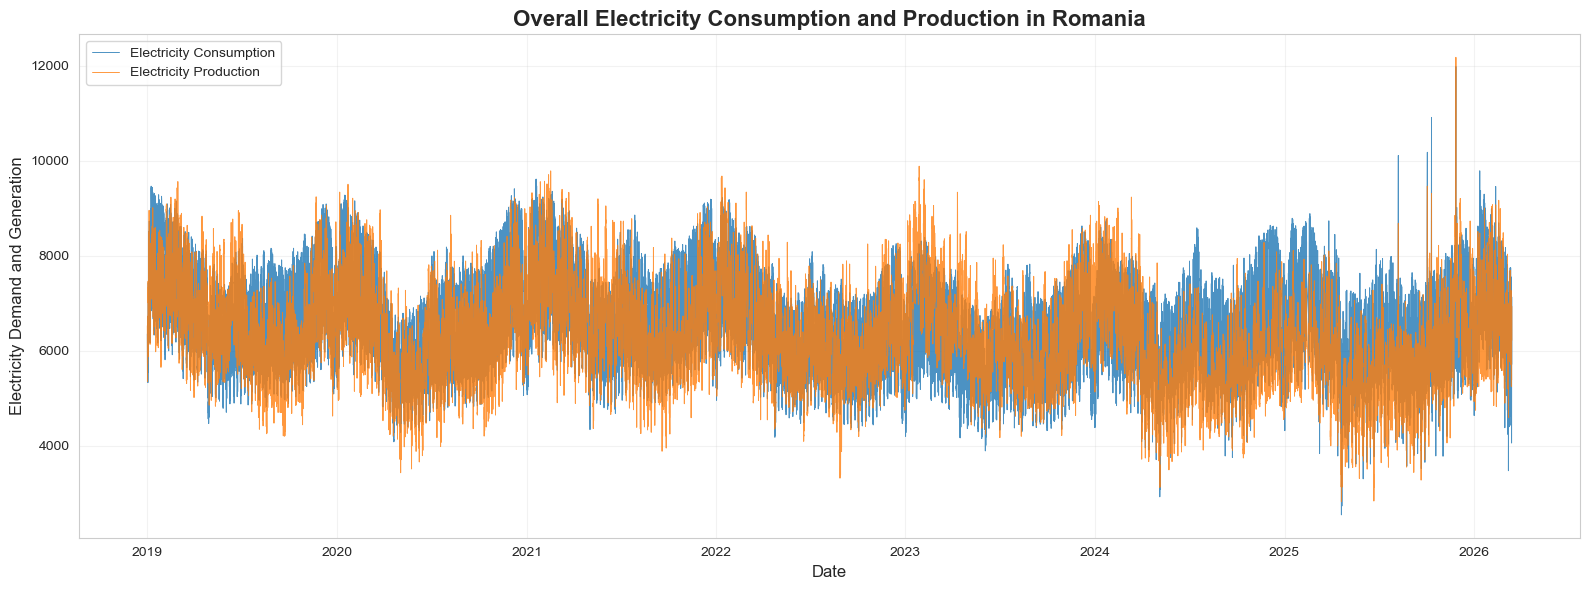

In [21]:
# ==========================================
# Overall Electricity Consumption
# and Production in Romania
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Load dataset
# ------------------------------------------

df = pd.read_csv("electricityConsumptionAndProduction.csv")

# Convert DateTime column
df["DateTime"] = pd.to_datetime(
    df["DateTime"],
    errors="coerce"
)

# Remove rows with invalid dates, if any
df = df.dropna(subset=["DateTime"])

# Sort chronologically
df = df.sort_values("DateTime").reset_index(drop=True)

# ------------------------------------------
# 2. Check dataset period
# ------------------------------------------

start_date = df["DateTime"].min()
end_date = df["DateTime"].max()

print("Dataset shape:", df.shape)
print("Start date:", start_date)
print("End date:", end_date)

# ------------------------------------------
# 3. Plot overall hourly series
# ------------------------------------------

plt.figure(figsize=(16, 6))

plt.plot(
    df["DateTime"],
    df["Consumption"],
    label="Electricity Consumption",
    linewidth=0.7,
    alpha=0.8
)

plt.plot(
    df["DateTime"],
    df["Production"],
    label="Electricity Production",
    linewidth=0.7,
    alpha=0.8
)

plt.title(
    "Overall Electricity Consumption and Production in Romania",
    fontsize=16,
    weight="semibold"
)

plt.xlabel("Date", fontsize=12)

# Use MW only if the dataset documentation confirms the unit
plt.ylabel(
    "Electricity Demand and Generation",
    fontsize=12
)

plt.legend(
    loc="upper left",
    frameon=True
)

plt.grid(
    True,
    alpha=0.25
)

plt.tight_layout()
plt.show()

#  Section 4.1 Descriptive Statistics

Table 4.1 Dataset Summary


,Item,Value
0,Number of Observations,62810
1,Number of Features,11
2,Start Date,2019-01-01 00:00:00
3,End Date,2026-03-14 23:00:00
4,Missing Values,0


Table 4.2 Descriptive Statistics


,mean,std,min,max
Consumption,6475.45,1062.46,2542.0,11986.0
Production,6305.89,1041.57,2818.0,12179.0
Nuclear,1278.14,240.52,562.0,2081.0
Wind,761.56,660.50,-26.0,2811.0
Hydroelectric,1756.52,672.16,175.0,4434.0
Oil and Gas,1169.51,441.78,146.0,2770.0
Coal,1087.09,337.68,220.0,2537.0
Solar,193.31,302.88,0.0,2331.0
Biomass,54.58,13.64,6.0,91.0
Gap,-169.57,827.48,-3070.0,3789.0


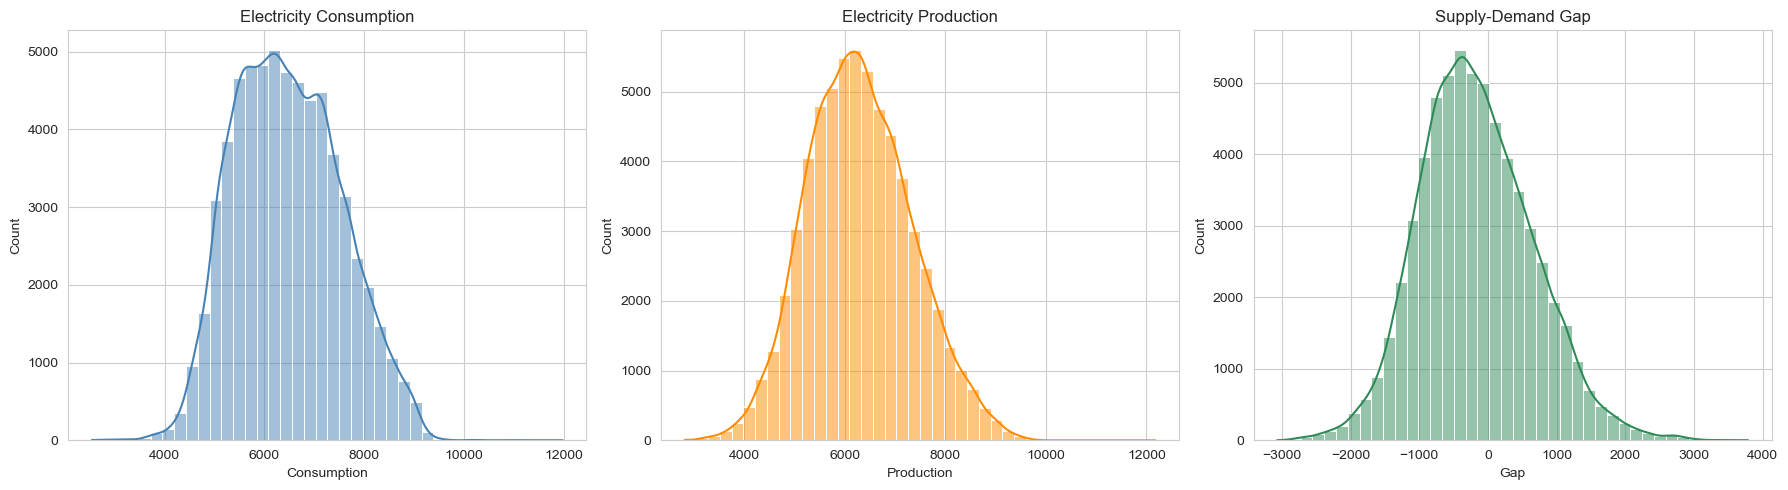

In [22]:
# ==========================================
# Section 4.1 Dataset Overview
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Ensure DateTime format
# ------------------------------------------

df["DateTime"] = pd.to_datetime(df["DateTime"])

# Sort chronologically
df = df.sort_values("DateTime").reset_index(drop=True)

# ------------------------------------------
# Create Supply-Demand Gap
# ------------------------------------------

df["Gap"] = df["Production"] - df["Consumption"]

# ==========================================
# Table 4.1 Dataset Summary
# ==========================================

summary_info = pd.DataFrame({
    "Item": [
        "Number of Observations",
        "Number of Features",
        "Start Date",
        "End Date",
        "Missing Values"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df["DateTime"].min(),
        df["DateTime"].max(),
        df.isnull().sum().sum()
    ]
})

print("Table 4.1 Dataset Summary")
display(summary_info)

# ==========================================
# Table 4.2 Descriptive Statistics
# ==========================================

numeric_cols = [
    "Consumption",
    "Production",
    "Nuclear",
    "Wind",
    "Hydroelectric",
    "Oil and Gas",
    "Coal",
    "Solar",
    "Biomass",
    "Gap"
]

stats_df = (
    df[numeric_cols]
    .describe()
    .T[
        ["mean", "std", "min", "max"]
    ]
    .round(2)
)

print("Table 4.2 Descriptive Statistics")
display(stats_df)

# ==========================================
# Figure 4.2 Distribution of Key Variables
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    df["Consumption"],
    bins=40,
    kde=True,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Electricity Consumption")
axes[0].set_xlabel("Consumption")

sns.histplot(
    df["Production"],
    bins=40,
    kde=True,
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Electricity Production")
axes[1].set_xlabel("Production")

sns.histplot(
    df["Gap"],
    bins=40,
    kde=True,
    ax=axes[2],
    color="seagreen"
)
axes[2].set_title("Supply-Demand Gap")
axes[2].set_xlabel("Gap")

plt.tight_layout()
plt.show()

# Section 4.2 Correlation Analysis
# Analyse relationships among electricity variables

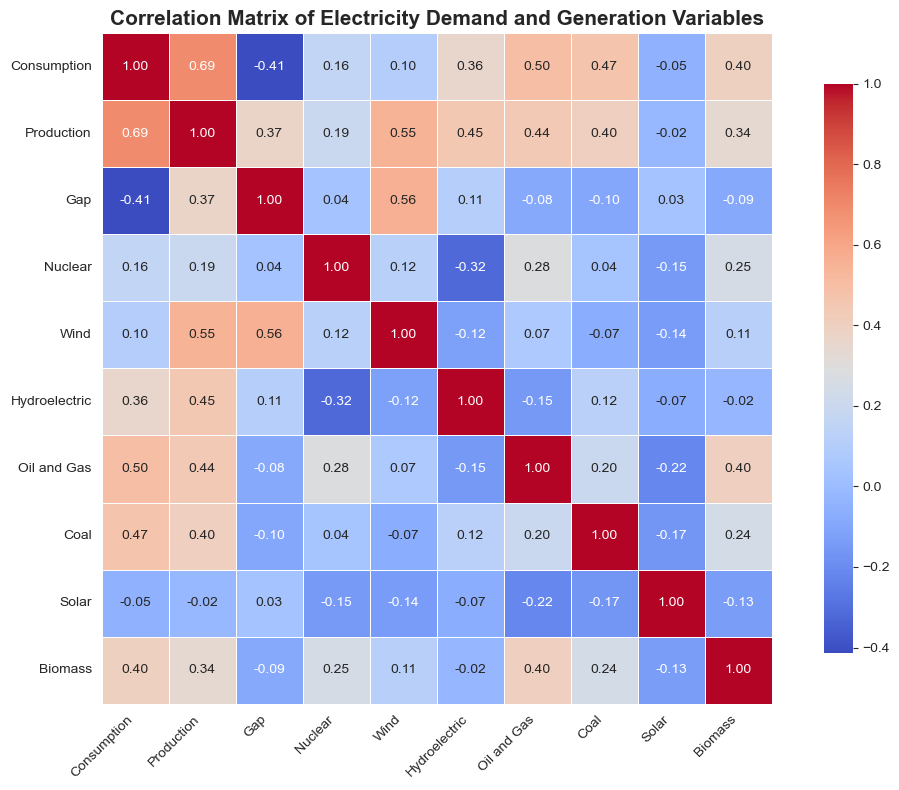

In [23]:
# ==========================================
# Section 4.2 Correlation Analysis
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ------------------------------------------
# Ensure Gap exists
# Gap = Production - Consumption
# ------------------------------------------
if "Gap" not in df.columns:
    df["Gap"] = df["Production"] - df["Consumption"]

# ------------------------------------------
# Select variables for correlation analysis
# ------------------------------------------
corr_cols = [
    "Consumption",
    "Production",
    "Gap",
    "Nuclear",
    "Wind",
    "Hydroelectric",
    "Oil and Gas",
    "Coal",
    "Solar",
    "Biomass"
]

corr_matrix = df[corr_cols].corr()

# ------------------------------------------
# Plot correlation heatmap
# ------------------------------------------
plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.85}
)

plt.title(
    "Correlation Matrix of Electricity Demand and Generation Variables",
    fontsize=15,
    weight="semibold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Section4.3  Long-Term Consumption Trend

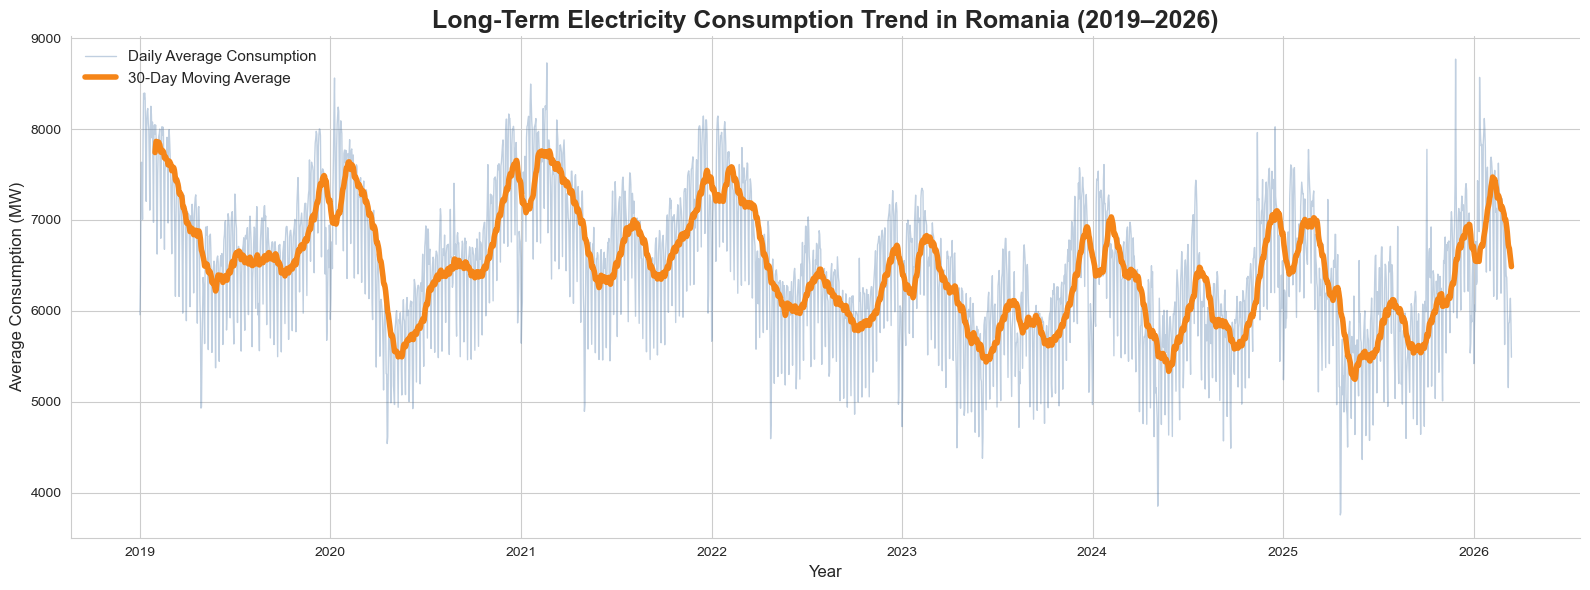

In [24]:
# ==========================================
# Section 4.3 Long-Term Electricity Consumption Trend
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ------------------------------------------
# Ensure DateTime is in datetime format
# ------------------------------------------
df["DateTime"] = pd.to_datetime(df["DateTime"])

# ------------------------------------------
# Calculate daily average electricity consumption
# ------------------------------------------
daily_consumption = (
    df.groupby(df["DateTime"].dt.date)["Consumption"]
      .mean()
)

# ------------------------------------------
# Calculate 30-day moving average
# ------------------------------------------
rolling_avg = (
    pd.Series(
        daily_consumption.values,
        index=pd.to_datetime(daily_consumption.index)
    )
    .rolling(window=30)
    .mean()
)

# ------------------------------------------
# Plot long-term consumption trend
# ------------------------------------------
plt.figure(figsize=(16, 6))

plt.plot(
    pd.to_datetime(daily_consumption.index),
    daily_consumption.values,
    linewidth=1,
    alpha=0.35,
    color="#4C78A8",
    label="Daily Average Consumption"
)

plt.plot(
    rolling_avg.index,
    rolling_avg.values,
    linewidth=4,
    color="#F58518",
    label="30-Day Moving Average"
)

plt.title(
    "Long-Term Electricity Consumption Trend in Romania (2019–2026)",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Consumption (MW)", fontsize=12)

plt.legend(frameon=False, fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

# Section 4.4 Long-Term Electricity Production Trend

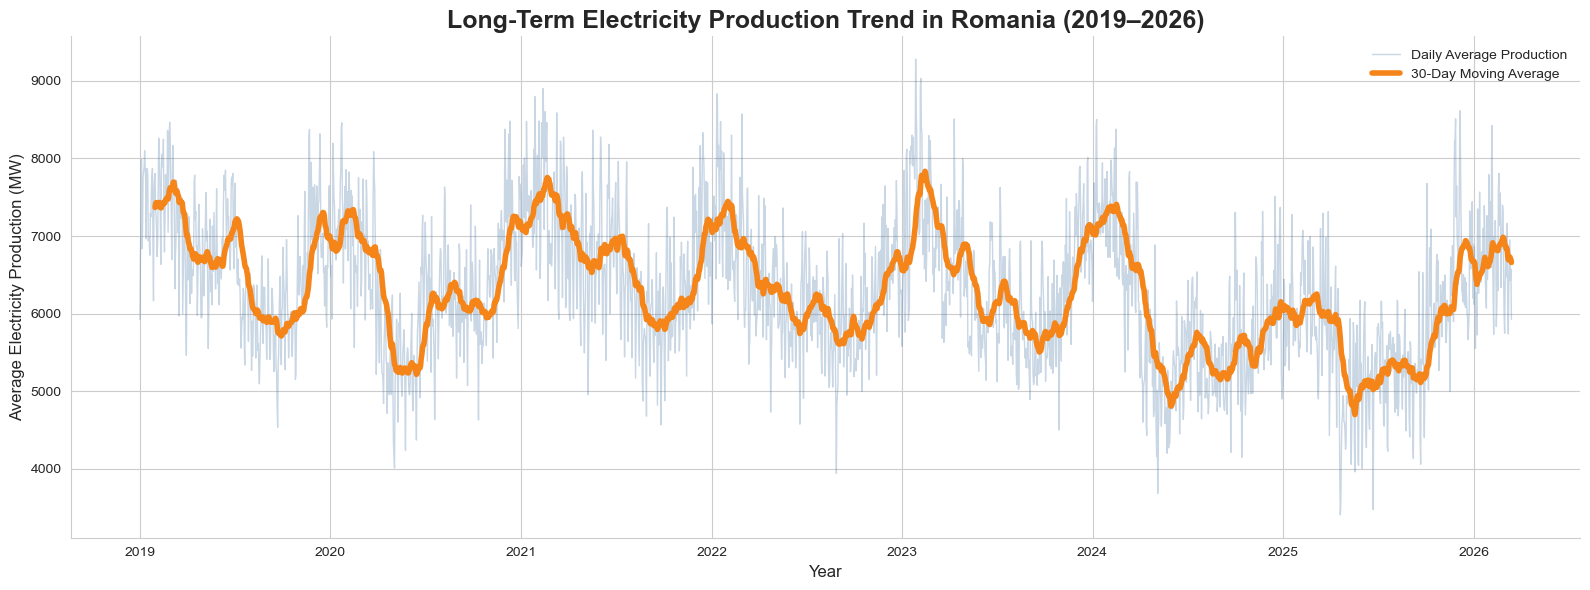

In [25]:
# ==========================================
# Section 4.4
# Long-Term Electricity Production Trend
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ------------------------------------------
# Ensure DateTime format
# ------------------------------------------
df["DateTime"] = pd.to_datetime(df["DateTime"])

# ------------------------------------------
# Daily average production
# ------------------------------------------
daily_production = (
    df.groupby(df["DateTime"].dt.date)["Production"]
      .mean()
)

daily_production = pd.Series(
    daily_production.values,
    index=pd.to_datetime(daily_production.index)
)

# ------------------------------------------
# 30-Day Moving Average
# ------------------------------------------
production_ma = (
    daily_production
    .rolling(window=30)
    .mean()
)

# ------------------------------------------
# Plot
# ------------------------------------------
plt.figure(figsize=(16,6))

# Raw data
plt.plot(
    daily_production.index,
    daily_production.values,
    color="#4C78A8",
    alpha=0.30,
    linewidth=1,
    label="Daily Average Production"
)

# Moving average
plt.plot(
    production_ma.index,
    production_ma.values,
    color="#F58518",
    linewidth=4,
    label="30-Day Moving Average"
)

plt.title(
    "Long-Term Electricity Production Trend in Romania (2019–2026)",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Electricity Production (MW)", fontsize=12)

plt.legend(frameon=False)

sns.despine()

plt.tight_layout()
plt.show()

# 4.5 seasonal Electricity Consumption Pattern

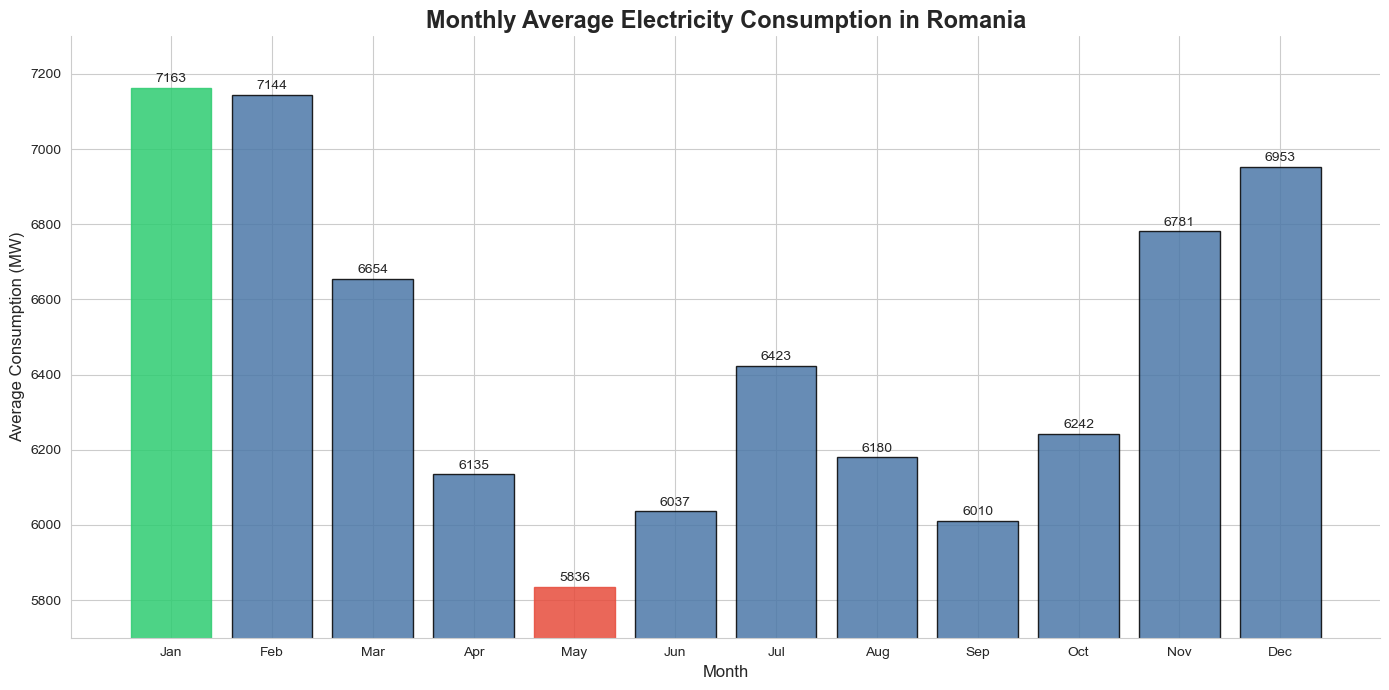

In [ ]:
# ==========================================
# Section 4.5 Seasonal Electricity Demand Pattern
# Final Publication Version
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ------------------------------------------
# Create month variable and monthly average consumption
# ------------------------------------------
df["Month"] = df["DateTime"].dt.month_name().str[:3]

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_cons = (
    df.groupby("Month")["Consumption"]
    .mean()
    .reindex(month_order)
)

# ------------------------------------------
# Plot bar chart
# ------------------------------------------
plt.figure(figsize=(14, 7))

bars = plt.bar(
    monthly_cons.index,
    monthly_cons.values,
    color="#4C78A8",
    edgecolor="black",
    alpha=0.85
)

# ------------------------------------------
# Highlight highest and lowest demand months
# ------------------------------------------
max_idx = monthly_cons.argmax()
min_idx = monthly_cons.argmin()

bars[max_idx].set_color("#2ECC71")  # Highest month
bars[min_idx].set_color("#E74C3C")  # Lowest month

# ------------------------------------------
# Add value labels
# ------------------------------------------
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 15,
        f"{h:.0f}",
        ha="center",
        fontsize=10
    )

# ------------------------------------------
# Labels and formatting
# ------------------------------------------
plt.title(
    "Monthly Average Electricity Consumption in Romania",
    fontsize=17,
    weight="semibold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Consumption (MW)", fontsize=12)

plt.ylim(0, monthly_cons.max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

# Section4.6 Seasonal Electricity Production Pattern

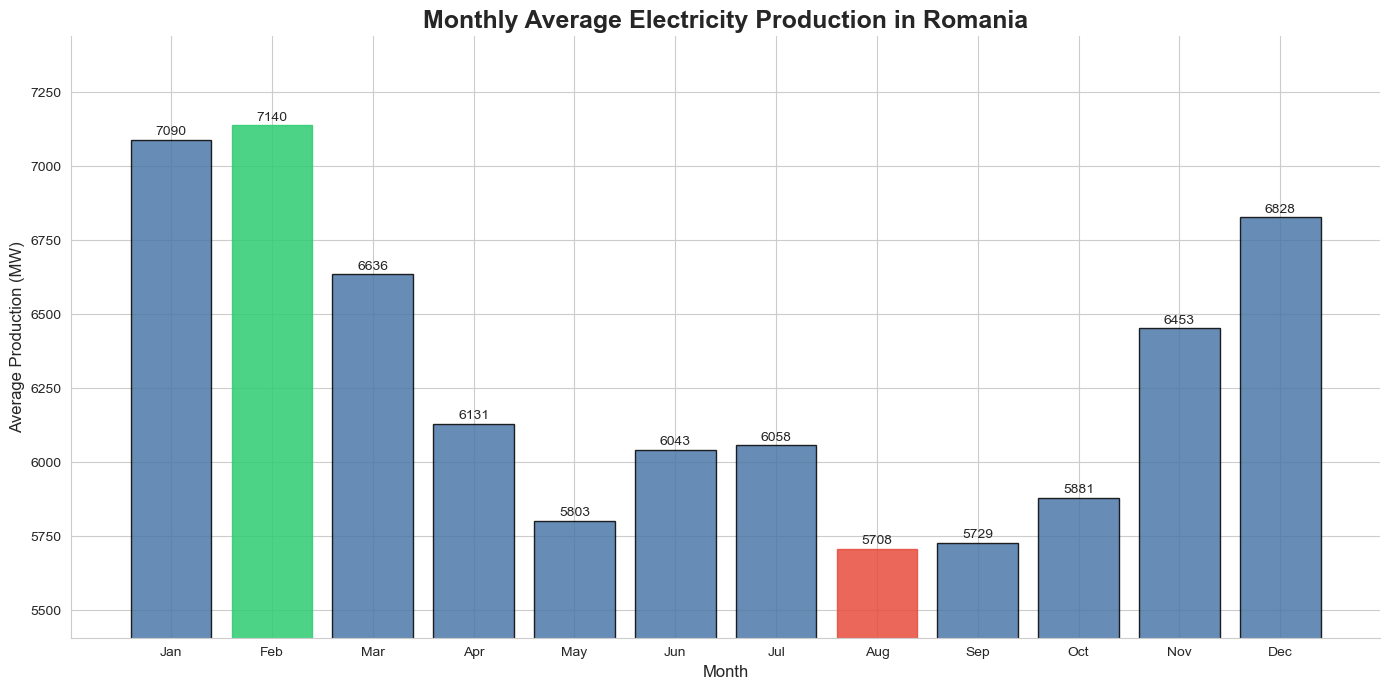

In [ ]:
# ==========================================
# Section 4.6
# Seasonal Electricity Production Pattern
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ------------------------------------------
# Ensure DateTime format
# ------------------------------------------
df["DateTime"] = pd.to_datetime(df["DateTime"])

# ------------------------------------------
# Create Month Variable
# ------------------------------------------
df["Month"] = df["DateTime"].dt.month_name().str[:3]

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# ------------------------------------------
# Monthly Average Production
# ------------------------------------------
monthly_prod = (
    df.groupby("Month")["Production"]
      .mean()
      .reindex(month_order)
)

# ------------------------------------------
# Plot
# ------------------------------------------
plt.figure(figsize=(14,7))

bars = plt.bar(
    monthly_prod.index,
    monthly_prod.values,
    color="#4C78A8",
    edgecolor="black",
    alpha=0.85
)

# Highlight highest and lowest months
max_idx = monthly_prod.argmax()
min_idx = monthly_prod.argmin()

bars[max_idx].set_color("#2ECC71")
bars[min_idx].set_color("#E74C3C")

# Add value labels
for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 15,
        f"{h:.0f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Monthly Average Electricity Production in Romania",
    fontsize=18,
    weight="bold"
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Average Production (MW)",
    fontsize=12
)

plt.ylim(
    0,
    monthly_prod.max() * 1.15
)
sns.despine()

plt.tight_layout()
plt.show()

# Section4.7 Supply-Demand Balance Analysis

Peak surplus:
2023-04 971.89 MW

Peak deficit:
2024-11 -900.09 MW


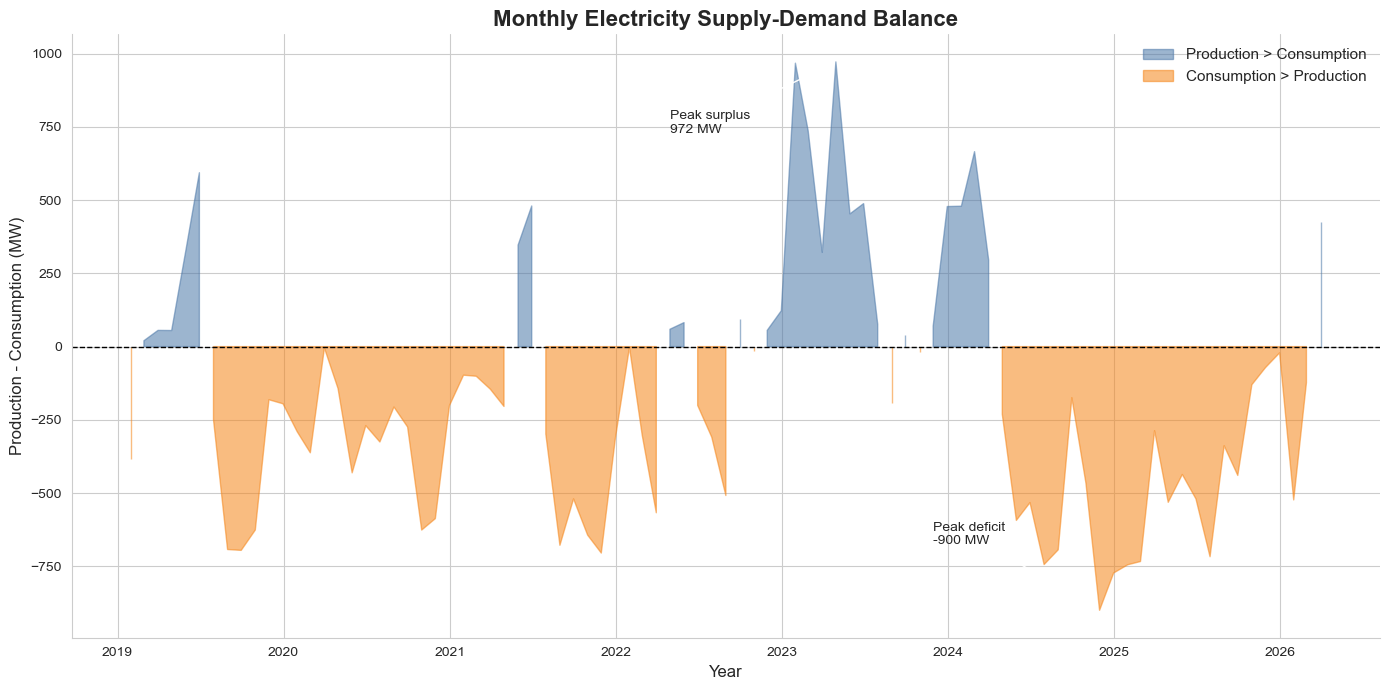

In [28]:
# ============================================================
# Section 4.7 Supply-Demand Balance Analysis
# ============================================================

# Ensure DateTime is in datetime format
df["DateTime"] = pd.to_datetime(df["DateTime"])

# Create monthly production and consumption averages
monthly_balance = (
    df.set_index("DateTime")[["Production", "Consumption"]]
      .resample("ME")
      .mean()
)

# Calculate monthly supply-demand gap
monthly_gap = (
    monthly_balance["Production"]
    - monthly_balance["Consumption"]
)

# ============================================================
# Automatically identify maximum surplus and maximum deficit
# ============================================================

peak_surplus_date = monthly_gap.idxmax()
peak_surplus_value = monthly_gap.max()

peak_deficit_date = monthly_gap.idxmin()
peak_deficit_value = monthly_gap.min()

print("Peak surplus:")
print(
    peak_surplus_date.strftime("%Y-%m"),
    f"{peak_surplus_value:.2f} MW"
)

print("\nPeak deficit:")
print(
    peak_deficit_date.strftime("%Y-%m"),
    f"{peak_deficit_value:.2f} MW"
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(14, 7))

# Positive gap: production exceeds consumption
plt.fill_between(
    monthly_gap.index,
    monthly_gap.values,
    0,
    where=monthly_gap.values >= 0,
    color="#4C78A8",
    alpha=0.55,
    label="Production > Consumption"
)

# Negative gap: consumption exceeds production
plt.fill_between(
    monthly_gap.index,
    monthly_gap.values,
    0,
    where=monthly_gap.values < 0,
    color="#F58518",
    alpha=0.55,
    label="Consumption > Production"
)

# Zero reference line
plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

# ============================================================
# Automatically annotate peak surplus
# ============================================================

plt.annotate(
    f"Peak surplus\n{peak_surplus_value:.0f} MW",
    xy=(
        peak_surplus_date,
        peak_surplus_value
    ),
    xytext=(
        peak_surplus_date - pd.DateOffset(months=12),
        peak_surplus_value * 0.75
    ),
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    ),
    fontsize=10
)

# ============================================================
# Automatically annotate peak deficit
# ============================================================

plt.annotate(
    f"Peak deficit\n{peak_deficit_value:.0f} MW",
    xy=(
        peak_deficit_date,
        peak_deficit_value
    ),
    xytext=(
        peak_deficit_date - pd.DateOffset(months=12),
        peak_deficit_value * 0.75
    ),
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    ),
    fontsize=10
)

# ============================================================
# Labels and formatting
# ============================================================

plt.title(
    "Monthly Electricity Supply-Demand Balance",
    fontsize=16,
    weight="semibold"
)

plt.xlabel(
    "Year",
    fontsize=12
)

plt.ylabel(
    "Production - Consumption (MW)",
    fontsize=12
)

plt.legend(
    frameon=False,
    fontsize=11
)

sns.despine()

plt.tight_layout()

plt.show()

# Section4.8 Generation Mix Analysis


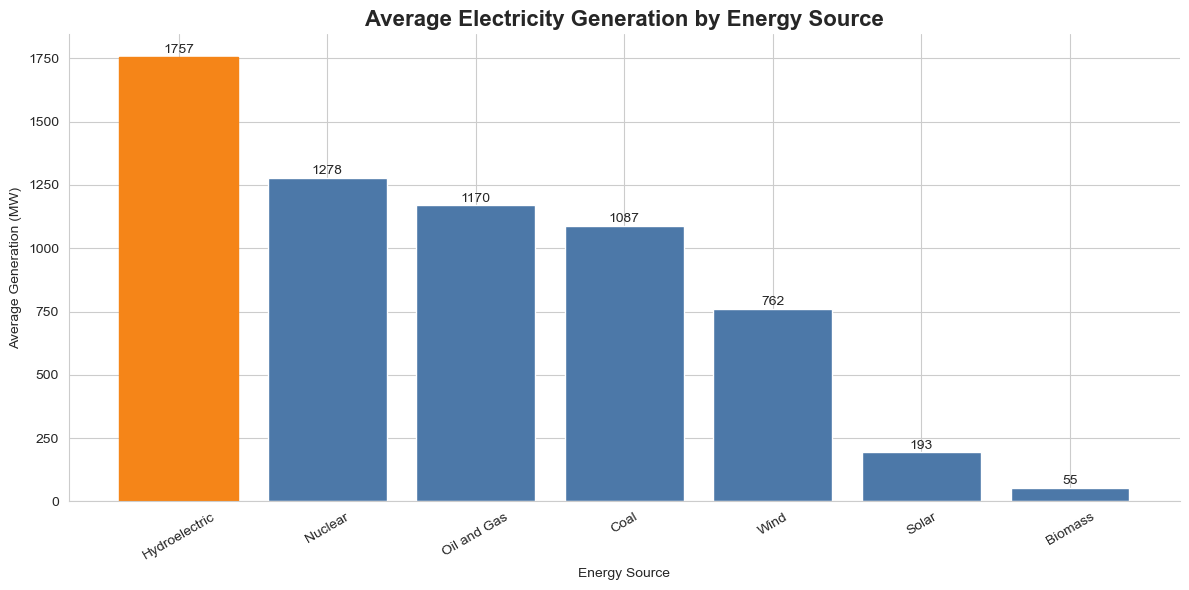

In [29]:

import matplotlib.pyplot as plt
import seaborn as sns

energy_cols = [
    "Nuclear",
    "Wind",
    "Hydroelectric",
    "Oil and Gas",
    "Coal",
    "Solar",
    "Biomass"
]

# average generation by source
avg_mix = df[energy_cols].mean().sort_values(ascending=False)

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

bars = plt.bar(
    avg_mix.index,
    avg_mix.values,
    color="#4C78A8"
)

# highlight top source
bars[0].set_color("#F58518")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+15,
        f"{h:.0f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Average Electricity Generation by Energy Source",
    fontsize=16,
    weight="semibold"
)

plt.xlabel("Energy Source")
plt.ylabel("Average Generation (MW)")

plt.xticks(rotation=30)
sns.despine()

plt.tight_layout()
plt.show()

# Section4.9 Generation Volatility Analysis

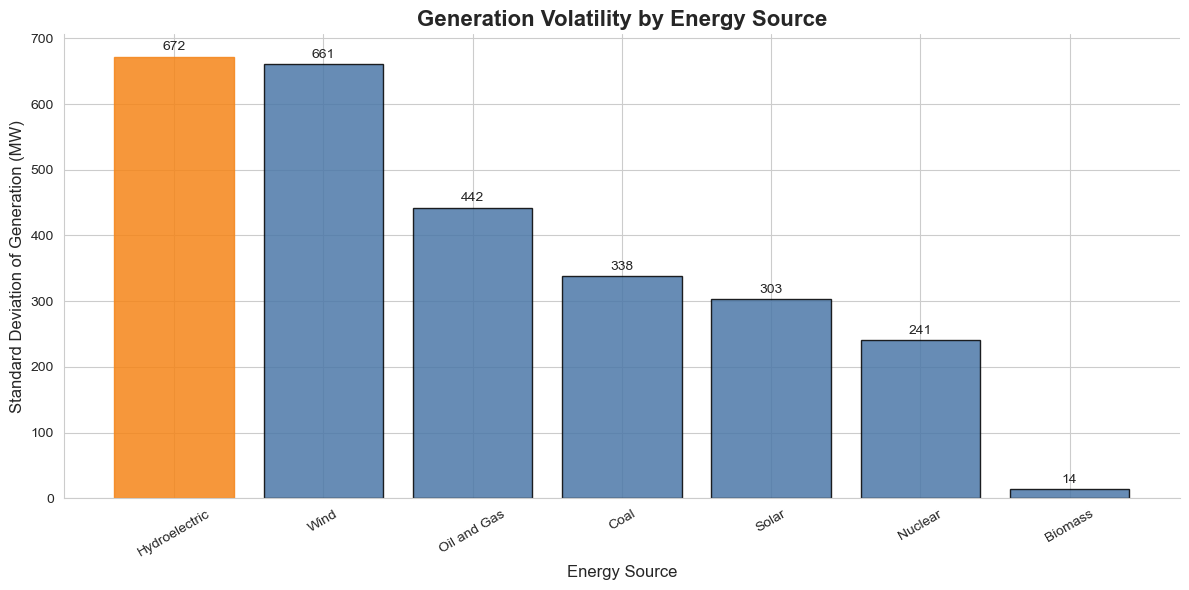

In [30]:
# ==========================================
# Section 4.9 Generation Volatility Analysis
# Standard Deviation by Energy Source
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

energy_cols = [
    "Nuclear",
    "Wind",
    "Hydroelectric",
    "Oil and Gas",
    "Coal",
    "Solar",
    "Biomass"
]

# Calculate volatility using standard deviation
volatility = df[energy_cols].std().sort_values(ascending=False)

plt.figure(figsize=(12,6))

bars = plt.bar(
    volatility.index,
    volatility.values,
    color="#4C78A8",
    edgecolor="black",
    alpha=0.85
)

# Highlight the most volatile source
bars[0].set_color("#F58518")

# Add value labels
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 10,
        f"{h:.0f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Generation Volatility by Energy Source",
    fontsize=16,
    weight="semibold"
)

plt.xlabel("Energy Source", fontsize=12)
plt.ylabel("Standard Deviation of Generation (MW)", fontsize=12)

plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

# 5.1 Problem Definition

This chapter focuses on forecasting electricity consumption in Romania using historical electricity market data. The target variable of the modelling process is hourly electricity consumption, while explanatory variables include electricity generation sources, time-related features, and historical demand patterns.

Predicting electricity demand is an important regression problem in energy systems, as accurate forecasts support generation planning, grid balancing, and operational efficiency. Underestimation may lead to electricity shortages, whereas overestimation may increase unnecessary generation costs.

Therefore, this study aims to develop and compare multiple machine learning models to predict electricity consumption and identify the most effective forecasting approach.

In [31]:
# target variable
y = df["Consumption"]

# predictors (later used in modelling)
X = df.drop(columns=["Consumption"])

# Chapter 5.2 Feature Engineering

In [32]:
# ==========================================
# Chapter 5.2 Feature Engineering
# ==========================================

import numpy as np
import pandas as pd

# Create a copy of the cleaned dataset
model_df = df.copy()

# Make sure DateTime is in datetime format
model_df["DateTime"] = pd.to_datetime(model_df["DateTime"])

# Sort observations chronologically
model_df = (
    model_df
    .sort_values("DateTime")
    .reset_index(drop=True)
)

# ==========================================
# 1. Calendar Features
# ==========================================

model_df["Hour"] = model_df["DateTime"].dt.hour
model_df["Day"] = model_df["DateTime"].dt.day
model_df["Month"] = model_df["DateTime"].dt.month
model_df["DayOfWeek"] = model_df["DateTime"].dt.dayofweek
model_df["Quarter"] = model_df["DateTime"].dt.quarter

# Weekend:
# Saturday = 5
# Sunday = 6
model_df["Weekend"] = (
    model_df["DayOfWeek"]
    .isin([5, 6])
    .astype(int)
)

# ==========================================
# 2. Cyclical Hour Features
# ==========================================

# Convert hour into sine and cosine components
# so that hour 23 and hour 0 are treated as adjacent
model_df["HourSin"] = np.sin(
    2 * np.pi * model_df["Hour"] / 24
)

model_df["HourCos"] = np.cos(
    2 * np.pi * model_df["Hour"] / 24
)

# ==========================================
# 3. Lag Features
# ==========================================

# Consumption one hour earlier
model_df["Lag_1"] = (
    model_df["Consumption"]
    .shift(1)
)

# Consumption at the same hour on the previous day
model_df["Lag_24"] = (
    model_df["Consumption"]
    .shift(24)
)

# Consumption at the same hour in the previous week
model_df["Lag_168"] = (
    model_df["Consumption"]
    .shift(168)
)

# ==========================================
# 4. Rolling Features
# Only historical values are used
# ==========================================

# Mean consumption over the previous 24 hours
model_df["RollingMean_24"] = (
    model_df["Consumption"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

# Standard deviation of consumption
# over the previous 24 hours
model_df["RollingStd_24"] = (
    model_df["Consumption"]
    .shift(1)
    .rolling(window=24)
    .std()
)

# ==========================================
# 5. Remove Missing Rows
# ==========================================

# Lag and rolling calculations create missing values
# at the beginning of the dataset
model_df = (
    model_df
    .dropna()
    .reset_index(drop=True)
)

# ==========================================
# 6. Check the Final Dataset
# ==========================================

print("Final model dataset shape:", model_df.shape)
print("Start time:", model_df["DateTime"].min())
print("End time:", model_df["DateTime"].max())

print("\nFirst five engineered observations:")

display(
    model_df[
        [
            "DateTime",
            "Consumption",
            "Hour",
            "HourSin",
            "HourCos",
            "DayOfWeek",
            "Weekend",
            "Lag_1",
            "Lag_24",
            "Lag_168",
            "RollingMean_24",
            "RollingStd_24"
        ]
    ].head()
)

Final model dataset shape: (62642, 24)
Start time: 2019-01-08 00:00:00
End time: 2026-03-14 23:00:00

First five engineered observations:


,DateTime,Consumption,Hour,HourSin,HourCos,DayOfWeek,Weekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingStd_24
0,2019-01-08 00:00:00,7106,0,0.000000,1.000000,1,0,7369.0,6512.0,6352.0,7883.083333,1027.411899
1,2019-01-08 01:00:00,6951,1,0.258819,0.965926,1,0,7106.0,6270.0,6116.0,7907.833333,999.728601
2,2019-01-08 02:00:00,6890,2,0.500000,0.866025,1,0,6951.0,6172.0,5873.0,7936.208333,960.100220
3,2019-01-08 03:00:00,6839,3,0.707107,0.707107,1,0,6890.0,6228.0,5682.0,7966.125000,912.756614
4,2019-01-08 04:00:00,6890,4,0.866025,0.500000,1,0,6839.0,6280.0,5557.0,7991.583333,869.673698


# Chapter 5.3 Train-Test Split

In [33]:
# ==========================================
# Chapter 5.3 Chronological Train-Test Split
# ==========================================

import pandas as pd

# ==========================================
# 1. Ensure Chronological Order
# ==========================================

model_df["DateTime"] = pd.to_datetime(model_df["DateTime"])

model_df = (
    model_df
    .sort_values("DateTime")
    .reset_index(drop=True)
)

# ==========================================
# 2. Define the Cut-off Date
# ==========================================

cutoff_date = pd.Timestamp("2024-01-01 00:00:00")

# Observations before 1 January 2024
# are used for model development
train_df = model_df[
    model_df["DateTime"] < cutoff_date
].copy()

# Observations from 1 January 2024 onwards
# form the independent test period
test_df = model_df[
    model_df["DateTime"] >= cutoff_date
].copy()

# ==========================================
# 3. Define Target Variable
# ==========================================

target_column = "Consumption"

y_train = train_df[target_column].copy()
y_test = test_df[target_column].copy()

# ==========================================
# 4. Define Predictor Variables
# ==========================================

# Consumption is the prediction target.
# DateTime is retained separately for alignment.
# Gap is excluded because it is calculated using Consumption.
excluded_columns = [
    "Consumption",
    "DateTime",
    "Gap"
]

X_train = train_df.drop(
    columns=excluded_columns
).copy()

X_test = test_df.drop(
    columns=excluded_columns
).copy()

# Save timestamps for later prediction alignment
train_timestamps = train_df["DateTime"].reset_index(drop=True)
test_timestamps = test_df["DateTime"].reset_index(drop=True)

# Reset indices so that X, y and timestamps align
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# ==========================================
# 5. Validation Checks
# ==========================================

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

assert len(X_train) == len(train_timestamps)
assert len(X_test) == len(test_timestamps)

assert X_train.columns.tolist() == X_test.columns.tolist()

assert train_timestamps.max() < cutoff_date
assert test_timestamps.min() >= cutoff_date

assert "Consumption" not in X_train.columns
assert "Gap" not in X_train.columns
assert "DateTime" not in X_train.columns

# ==========================================
# 6. Display Split Information
# ==========================================

total_samples = len(model_df)

train_percentage = (
    len(train_df) / total_samples
) * 100

test_percentage = (
    len(test_df) / total_samples
) * 100

print("=" * 60)
print("CHRONOLOGICAL TRAIN-TEST SPLIT")
print("=" * 60)

print("\nCut-off date:")
print(cutoff_date)

print("\nComplete modelling dataset:")
print("Samples:", total_samples)
print(
    "Period:",
    model_df["DateTime"].min(),
    "to",
    model_df["DateTime"].max()
)

print("\nTraining set:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print(
    "Period:",
    train_timestamps.min(),
    "to",
    train_timestamps.max()
)
print(
    "Percentage:",
    f"{train_percentage:.2f}%"
)

print("\nTest set:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print(
    "Period:",
    test_timestamps.min(),
    "to",
    test_timestamps.max()
)
print(
    "Percentage:",
    f"{test_percentage:.2f}%"
)

print("\nNumber of predictor variables:")
print(X_train.shape[1])

print("\nPredictor variables:")
for number, feature in enumerate(
    X_train.columns,
    start=1
):
    print(f"{number}. {feature}")

CHRONOLOGICAL TRAIN-TEST SPLIT

Cut-off date:
2024-01-01 00:00:00

Complete modelling dataset:
Samples: 62642
Period: 2019-01-08 00:00:00 to 2026-03-14 23:00:00

Training set:
X_train shape: (43660, 21)
y_train shape: (43660,)
Period: 2019-01-08 00:00:00 to 2023-12-31 23:00:00
Percentage: 69.70%

Test set:
X_test shape: (18982, 21)
y_test shape: (18982,)
Period: 2024-01-01 00:00:00 to 2026-03-14 23:00:00
Percentage: 30.30%

Number of predictor variables:
21

Predictor variables:
1. Production
2. Nuclear
3. Wind
4. Hydroelectric
5. Oil and Gas
6. Coal
7. Solar
8. Biomass
9. Month
10. Hour
11. Day
12. DayOfWeek
13. Quarter
14. Weekend
15. HourSin
16. HourCos
17. Lag_1
18. Lag_24
19. Lag_168
20. RollingMean_24
21. RollingStd_24


# Chapter 5.4 Baseline Model - Random Forest

In [34]:
# ==========================================
# Chapter 5.4 Baseline Model - Random Forest
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ------------------------------------------
# Train model
# ------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ------------------------------------------
# Prediction
# ------------------------------------------
rf_pred = rf_model.predict(X_test)

# ------------------------------------------
# Evaluation Metrics
# ------------------------------------------
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("----------------------")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

Random Forest Results
----------------------
MAE : 139.8
RMSE: 209.74
R²  : 0.9599


# Chapter 5.5 Actual vs Predicted Comparison    

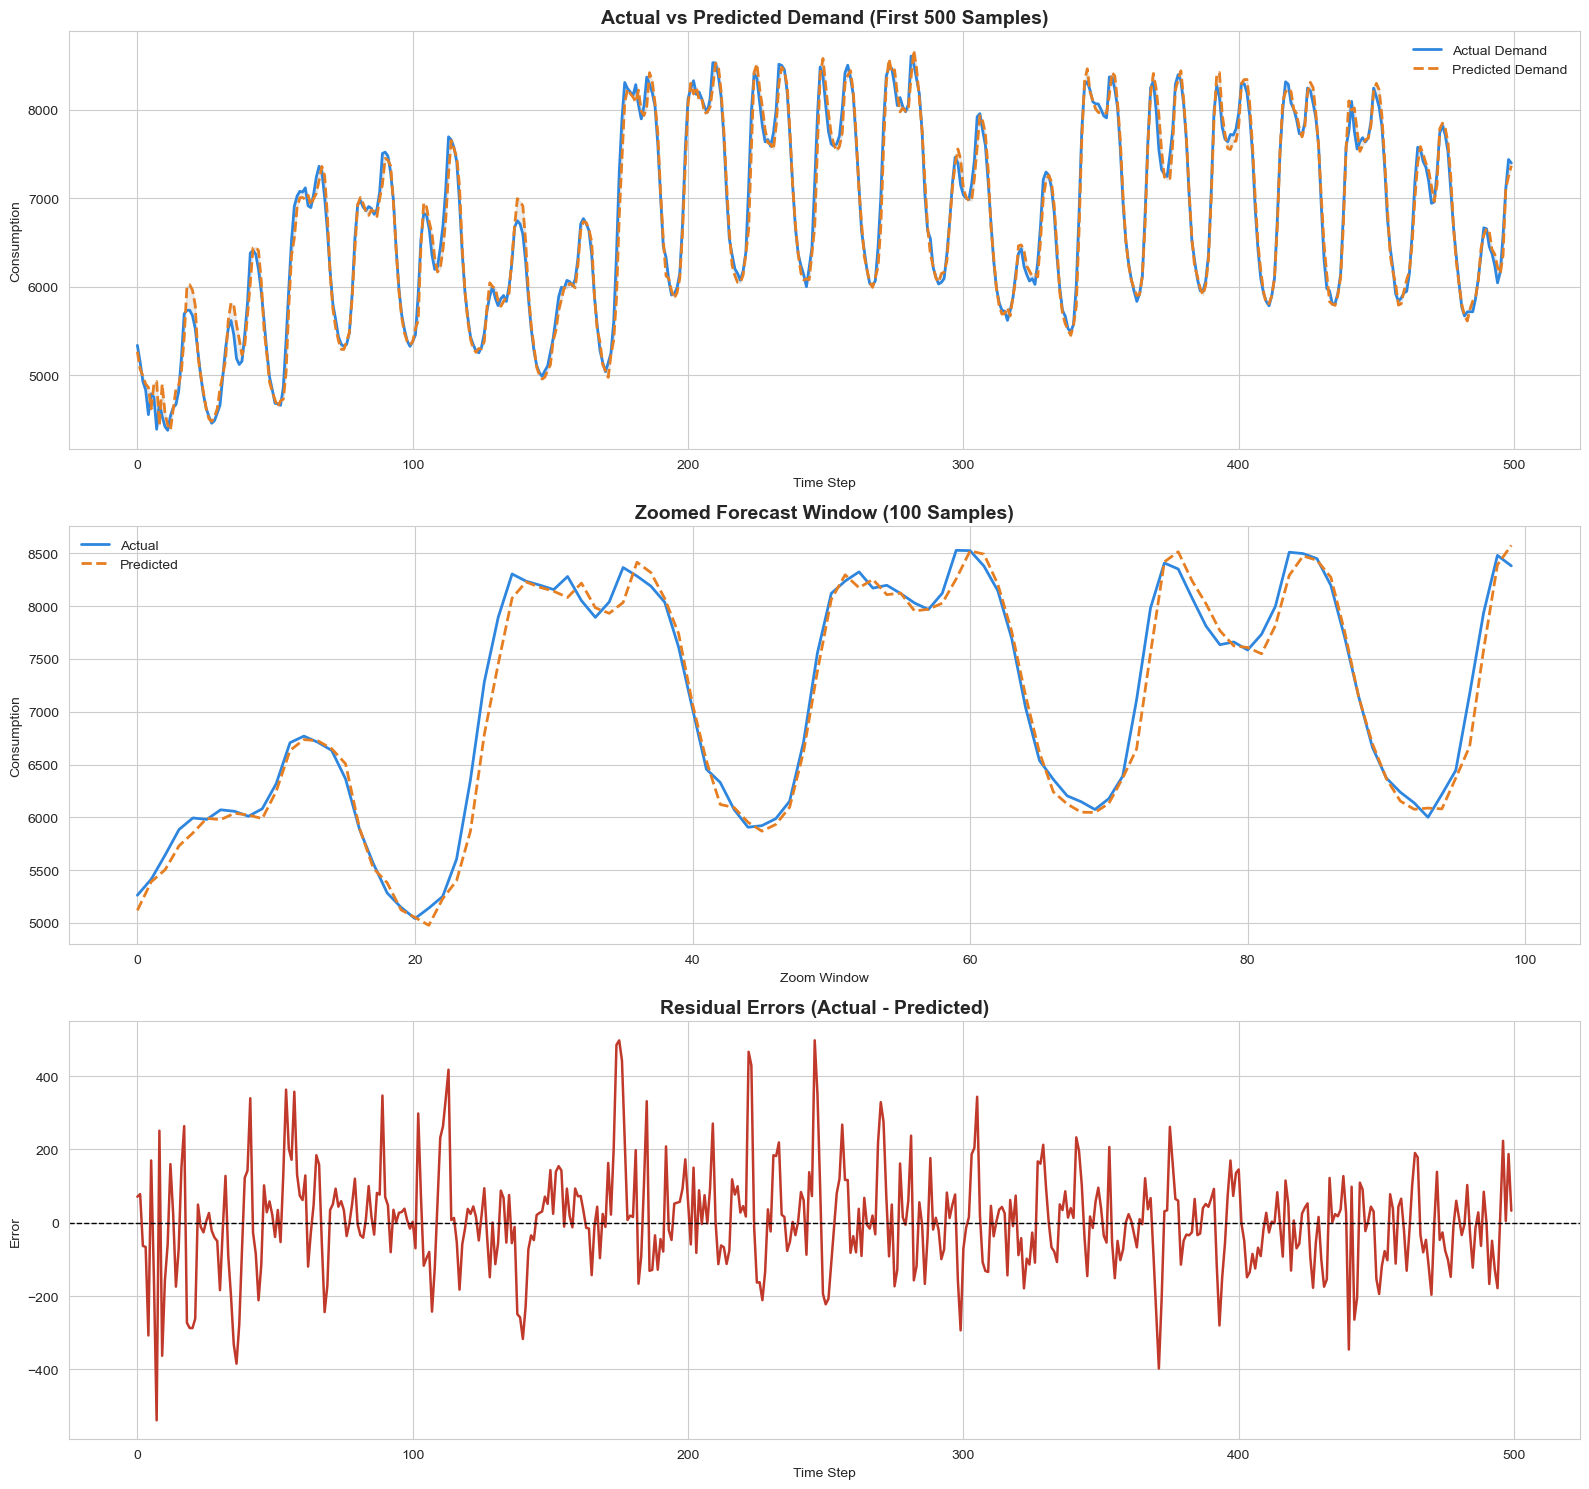

In [35]:


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# ------------------------------------------
# Prediction error
# ------------------------------------------
errors = y_test.values - rf_pred

# ------------------------------------------
# Create 3 figures
# ------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

# =====================================================
# Figure 1: Full Comparison
# =====================================================
n = 500

axes[0].plot(
    y_test.values[:n],
    label="Actual Demand",
    linewidth=2,
    color="#2E86DE"
)

axes[0].plot(
    rf_pred[:n],
    label="Predicted Demand",
    linewidth=2,
    linestyle="--",
    color="#E67E22"
)

axes[0].fill_between(
    range(n),
    y_test.values[:n],
    rf_pred[:n],
    color="gray",
    alpha=0.15
)

axes[0].set_title(
    "Actual vs Predicted Demand (First 500 Samples)",
    fontsize=14,
    weight="semibold"
)

axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Consumption")
axes[0].legend(frameon=False)


# =====================================================
# Figure 2: Zoomed Region
# =====================================================
start = 150
end = 250

axes[1].plot(
    y_test.values[start:end],
    label="Actual",
    linewidth=2,
    color="#2E86DE"
)

axes[1].plot(
    rf_pred[start:end],
    label="Predicted",
    linewidth=2,
    linestyle="--",
    color="#E67E22"
)

axes[1].set_title(
    "Zoomed Forecast Window (100 Samples)",
    fontsize=14,
    weight="semibold"
)

axes[1].set_xlabel("Zoom Window")
axes[1].set_ylabel("Consumption")
axes[1].legend(frameon=False)


# =====================================================
# Figure 3: Residual Errors
# =====================================================
axes[2].plot(
    errors[:500],
    color="#C0392B",
    linewidth=1.8
)

axes[2].axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1
)

axes[2].set_title(
    "Residual Errors (Actual - Predicted)",
    fontsize=14,
    weight="semibold"
)

axes[2].set_xlabel("Time Step")
axes[2].set_ylabel("Error")

# ------------------------------------------
# Final layout
# ------------------------------------------
plt.tight_layout()
plt.show()

# 5.6 Comparative Model Evaluation

SECTION 5.6 COMPARATIVE MODEL EVALUATION

Training shape: (43660, 21)
Test shape: (18982, 21)
Number of predictors: 21

Predictor variables:
1. Production
2. Nuclear
3. Wind
4. Hydroelectric
5. Oil and Gas
6. Coal
7. Solar
8. Biomass
9. Month
10. Hour
11. Day
12. DayOfWeek
13. Quarter
14. Weekend
15. HourSin
16. HourCos
17. Lag_1
18. Lag_24
19. Lag_168
20. RollingMean_24
21. RollingStd_24

------------------------------------------------------------
Linear Regression
------------------------------------------------------------
MAE: 221.65 MW
RMSE: 304.09 MW
R²: 0.9157
Training time: 0.02 seconds

------------------------------------------------------------
Random Forest
------------------------------------------------------------
MAE: 139.80 MW
RMSE: 209.74 MW
R²: 0.9599
Training time: 9.40 seconds

------------------------------------------------------------
Extra Trees
------------------------------------------------------------
MAE: 137.36 MW
RMSE: 210.43 MW
R²: 0.9596
Training time

,Model,MAE,RMSE,R2,Training Time
0,Gradient Boosting,132.82,200.42,0.9634,58.64
1,Voting Regressor,133.12,202.70,0.9626,71.48
2,Random Forest,139.80,209.74,0.9599,9.40
3,Extra Trees,137.36,210.43,0.9596,2.03
4,MLP + Augmentation,158.65,265.97,0.9355,20.31
5,MLP Neural Network,166.39,268.65,0.9342,13.54
6,Linear Regression,221.65,304.09,0.9157,0.02



Best model based on RMSE:
Gradient Boosting
MAE: 132.82 MW
RMSE: 200.42 MW
R²: 0.9634


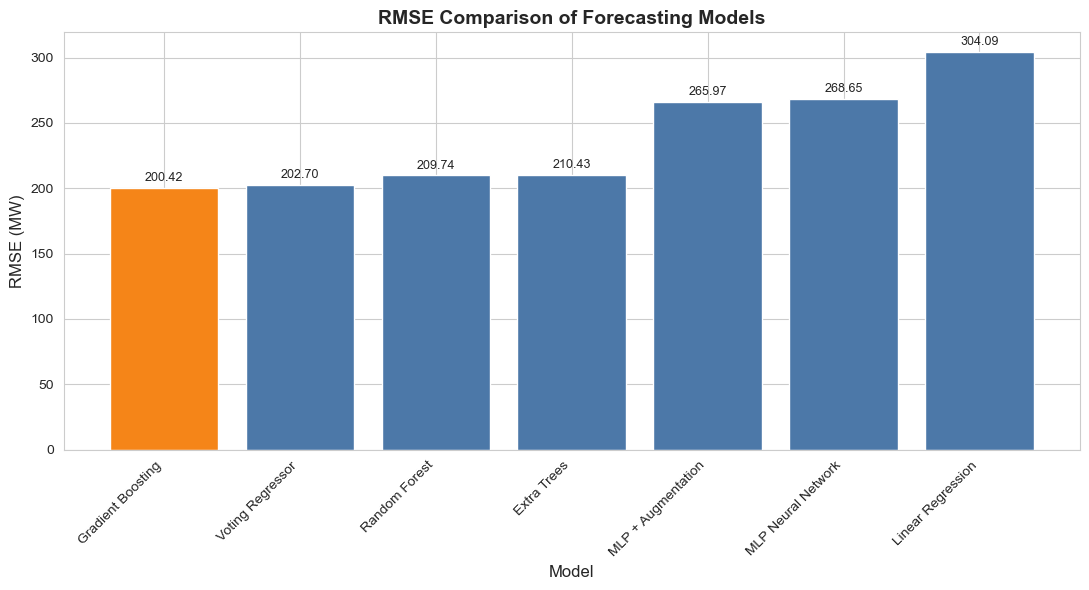


First five comparative predictions:


,DateTime,Actual,Linear Regression,Random Forest,Extra Trees,Gradient Boosting,Voting Regressor,MLP Neural Network,MLP + Augmentation
0,2024-01-01 00:00:00,5338,5464.569763,5266.949000,5281.077454,5334.442902,5294.156452,5203.293787,5217.582427
1,2024-01-01 01:00:00,5148,5220.298567,5069.897813,5100.607123,5173.150742,5114.551893,5096.133924,5088.066944
2,2024-01-01 02:00:00,4931,5065.828173,4994.075599,5014.004844,5092.312714,5033.464385,5004.343893,4994.940418
3,2024-01-01 03:00:00,4836,4941.712225,4902.090284,4895.682610,4812.880115,4870.217670,4898.238373,4856.127712
4,2024-01-01 04:00:00,4556,4981.397700,4863.386942,4862.022414,4792.525614,4839.311657,4889.539660,4853.762783



Best tabular prediction array saved as: best_tabular_pred


In [36]:
# ============================================================
# Section 5.6 Comparative Model Evaluation
# Traditional, Ensemble and Neural Network Models
# ============================================================

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor
)

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. Reproducibility and Input Checks
# ============================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

required_variables = [
    "X_train",
    "X_test",
    "y_train",
    "y_test"
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise NameError(
            f"{variable_name} is not available. "
            "Run Sections 5.2 and 5.3 first."
        )

if len(X_train) != len(y_train):
    raise ValueError(
        "X_train and y_train are not aligned."
    )

if len(X_test) != len(y_test):
    raise ValueError(
        "X_test and y_test are not aligned."
    )

if X_train.columns.tolist() != X_test.columns.tolist():
    raise ValueError(
        "Training and test predictor columns do not match."
    )

print("=" * 70)
print("SECTION 5.6 COMPARATIVE MODEL EVALUATION")
print("=" * 70)

print("\nTraining shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of predictors:", X_train.shape[1])

print("\nPredictor variables:")
for number, feature in enumerate(
    X_train.columns,
    start=1
):
    print(f"{number}. {feature}")


# ============================================================
# 2. Results Storage and Evaluation Function
# ============================================================

results = []


def evaluate_model(
    model_name,
    y_true,
    y_pred,
    training_time
):
    """
    Calculate and store regression performance metrics.
    """

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training Time": training_time
    })

    print("\n" + "-" * 60)
    print(model_name)
    print("-" * 60)

    print(f"MAE: {mae:.2f} MW")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"R²: {r2:.4f}")
    print(
        f"Training time: "
        f"{training_time:.2f} seconds"
    )


# ============================================================
# 3. Linear Regression
# ============================================================

start_time = time.time()

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

lr_training_time = (
    time.time() - start_time
)

evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred,
    lr_training_time
)


# ============================================================
# 4. Random Forest
# ============================================================

start_time = time.time()

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_training_time = (
    time.time() - start_time
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_training_time
)


# ============================================================
# 5. Extra Trees
# ============================================================

start_time = time.time()

et_model = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

et_model.fit(
    X_train,
    y_train
)

et_pred = et_model.predict(
    X_test
)

et_training_time = (
    time.time() - start_time
)

evaluate_model(
    "Extra Trees",
    y_test,
    et_pred,
    et_training_time
)


# ============================================================
# 6. Gradient Boosting
# ============================================================

start_time = time.time()

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=RANDOM_SEED
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(
    X_test
)

gb_training_time = (
    time.time() - start_time
)

evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred,
    gb_training_time
)


# ============================================================
# 7. Voting Regressor
# Random Forest + Extra Trees + Gradient Boosting
# ============================================================

start_time = time.time()

voting_model = VotingRegressor(
    estimators=[
        (
            "rf",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=RANDOM_SEED,
                n_jobs=-1
            )
        ),
        (
            "et",
            ExtraTreesRegressor(
                n_estimators=200,
                max_depth=15,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=RANDOM_SEED,
                n_jobs=-1
            )
        ),
        (
            "gb",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                random_state=RANDOM_SEED
            )
        )
    ]
)

voting_model.fit(
    X_train,
    y_train
)

voting_pred = voting_model.predict(
    X_test
)

voting_training_time = (
    time.time() - start_time
)

evaluate_model(
    "Voting Regressor",
    y_test,
    voting_pred,
    voting_training_time
)


# ============================================================
# 8. MLP Neural Network
# Standardised Input Features
# ============================================================

mlp_scaler = StandardScaler()

# Fit scaler only on the training data
X_train_scaled_mlp = (
    mlp_scaler.fit_transform(
        X_train
    )
)

X_test_scaled_mlp = (
    mlp_scaler.transform(
        X_test
    )
)

start_time = time.time()

mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=15,
    random_state=RANDOM_SEED
)

mlp_model.fit(
    X_train_scaled_mlp,
    y_train
)

mlp_pred = mlp_model.predict(
    X_test_scaled_mlp
)

mlp_training_time = (
    time.time() - start_time
)

evaluate_model(
    "MLP Neural Network",
    y_test,
    mlp_pred,
    mlp_training_time
)


# ============================================================
# 9. MLP Training-Data Augmentation
# Controlled Gaussian Noise Injection
# ============================================================

np.random.seed(RANDOM_SEED)

# Continuous numerical features selected for augmentation.
# Discrete calendar variables are intentionally excluded.
noise_cols = [
    "Production",
    "Nuclear",
    "Wind",
    "Hydroelectric",
    "Oil and Gas",
    "Coal",
    "Solar",
    "Biomass",
    "HourSin",
    "HourCos",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "RollingMean_24",
    "RollingStd_24"
]

# Check that every requested augmentation feature exists
available_noise_cols = [
    column
    for column in noise_cols
    if column in X_train.columns
]

missing_noise_cols = [
    column
    for column in noise_cols
    if column not in X_train.columns
]

if missing_noise_cols:
    print(
        "\nWarning: The following augmentation "
        "features were not found:"
    )
    print(missing_noise_cols)

print("\nFeatures used for MLP augmentation:")
print(available_noise_cols)

# Create a noisy copy of the training predictors
X_train_noisy = X_train.copy()

for column in available_noise_cols:

    feature_std = X_train[column].std()

    if (
        pd.notna(feature_std)
        and feature_std > 0
    ):
        noise = np.random.normal(
            loc=0.0,
            scale=feature_std * 0.01,
            size=len(X_train_noisy)
        )

        X_train_noisy[column] = (
            X_train_noisy[column]
            .astype(float)
            + noise
        )

# Combine original and noisy training predictors
X_train_augmented = pd.concat(
    [
        X_train,
        X_train_noisy
    ],
    axis=0,
    ignore_index=True
)

# Duplicate target values
y_train_augmented = pd.concat(
    [
        y_train,
        y_train
    ],
    axis=0,
    ignore_index=True
)

print("\nOriginal MLP training shape:")
print(X_train.shape)

print("\nAugmented MLP training shape:")
print(X_train_augmented.shape)


# ============================================================
# 10. Scale Augmented MLP Inputs
# ============================================================

mlp_aug_scaler = StandardScaler()

X_train_augmented_scaled = (
    mlp_aug_scaler.fit_transform(
        X_train_augmented
    )
)

X_test_augmented_scaled = (
    mlp_aug_scaler.transform(
        X_test
    )
)


# ============================================================
# 11. MLP with Data Augmentation
# ============================================================

start_time = time.time()

mlp_aug_model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=15,
    random_state=RANDOM_SEED
)

mlp_aug_model.fit(
    X_train_augmented_scaled,
    y_train_augmented
)

mlp_aug_pred = mlp_aug_model.predict(
    X_test_augmented_scaled
)

mlp_aug_training_time = (
    time.time() - start_time
)

evaluate_model(
    "MLP + Augmentation",
    y_test,
    mlp_aug_pred,
    mlp_aug_training_time
)


# ============================================================
# 12. Create Final Comparative Results Table
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = (
    results_df
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TABLE 5.6 COMPARATIVE MODEL PERFORMANCE")
print("=" * 70)

display(
    results_df.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 4,
        "Training Time": 2
    })
)


# ============================================================
# 13. Identify the Best Tabular Model
# ============================================================

best_model_row = (
    results_df.iloc[0]
)

best_tabular_model_name = (
    best_model_row["Model"]
)

best_tabular_mae = (
    best_model_row["MAE"]
)

best_tabular_rmse = (
    best_model_row["RMSE"]
)

best_tabular_r2 = (
    best_model_row["R2"]
)

print("\nBest model based on RMSE:")
print(best_tabular_model_name)

print(
    f"MAE: {best_tabular_mae:.2f} MW"
)

print(
    f"RMSE: {best_tabular_rmse:.2f} MW"
)

print(
    f"R²: {best_tabular_r2:.4f}"
)


# ============================================================
# 14. Figure  Comparative RMSE
# ============================================================
best_rmse_position = int(
    np.argmin(results_df["RMSE"].to_numpy())
)

# Default colour for all bars
bar_colours = ["#4C78A8"] * len(results_df)

# Highlight the best model
bar_colours[best_rmse_position] = "#F58518"

# Create figure
plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    results_df["Model"],
    results_df["RMSE"],
    color=bar_colours
)

plt.title(
    "RMSE Comparison of Forecasting Models",
    fontsize=14,
    fontweight="semibold"
)

plt.xlabel(
    "Model",
    fontsize=12
)

plt.ylabel(
    "RMSE (MW)",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

# Add RMSE value above each bar
for bar, value in zip(
    bars,
    results_df["RMSE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ============================================================
# 15. Save Prediction-Level Results
# ============================================================

model_predictions = pd.DataFrame({
    "DateTime": (
        test_timestamps
        if "test_timestamps" in globals()
        else np.arange(len(y_test))
    ),
    "Actual": y_test.to_numpy(),
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Extra Trees": et_pred,
    "Gradient Boosting": gb_pred,
    "Voting Regressor": voting_pred,
    "MLP Neural Network": mlp_pred,
    "MLP + Augmentation": mlp_aug_pred
})

print("\nFirst five comparative predictions:")

display(
    model_predictions.head()
)


# ============================================================
# 16. Save Best Model Prediction Variables
# ============================================================

prediction_lookup = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Extra Trees": et_pred,
    "Gradient Boosting": gb_pred,
    "Voting Regressor": voting_pred,
    "MLP Neural Network": mlp_pred,
    "MLP + Augmentation": mlp_aug_pred
}

best_tabular_pred = (
    prediction_lookup[
        best_tabular_model_name
    ]
)

print(
    "\nBest tabular prediction array saved as: "
    "best_tabular_pred"
)

## 5.7 Feature Importance Analysis

SECTION 5.7 GRADIENT BOOSTING FEATURE IMPORTANCE
       Feature Importance
         Lag_1   0.915335
       Lag_168   0.032054
       HourCos   0.017175
       HourSin   0.012300
          Hour   0.007471
        Lag_24   0.006079
         Solar   0.003616
     DayOfWeek   0.001357
RollingMean_24   0.001274
         Month   0.000795
 Hydroelectric   0.000465
       Weekend   0.000375
 RollingStd_24   0.000369
    Production   0.000325
          Coal   0.000289
   Oil and Gas   0.000213
           Day   0.000169
       Nuclear   0.000127
       Biomass   0.000101
       Quarter   0.000069
          Wind   0.000042


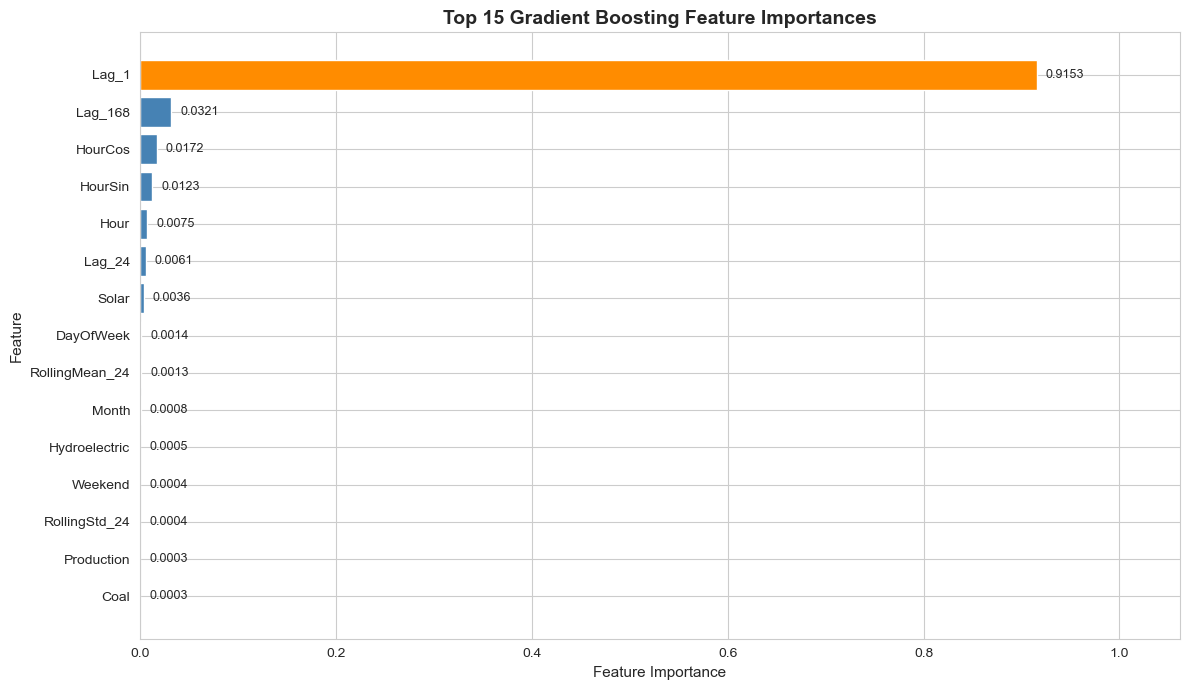

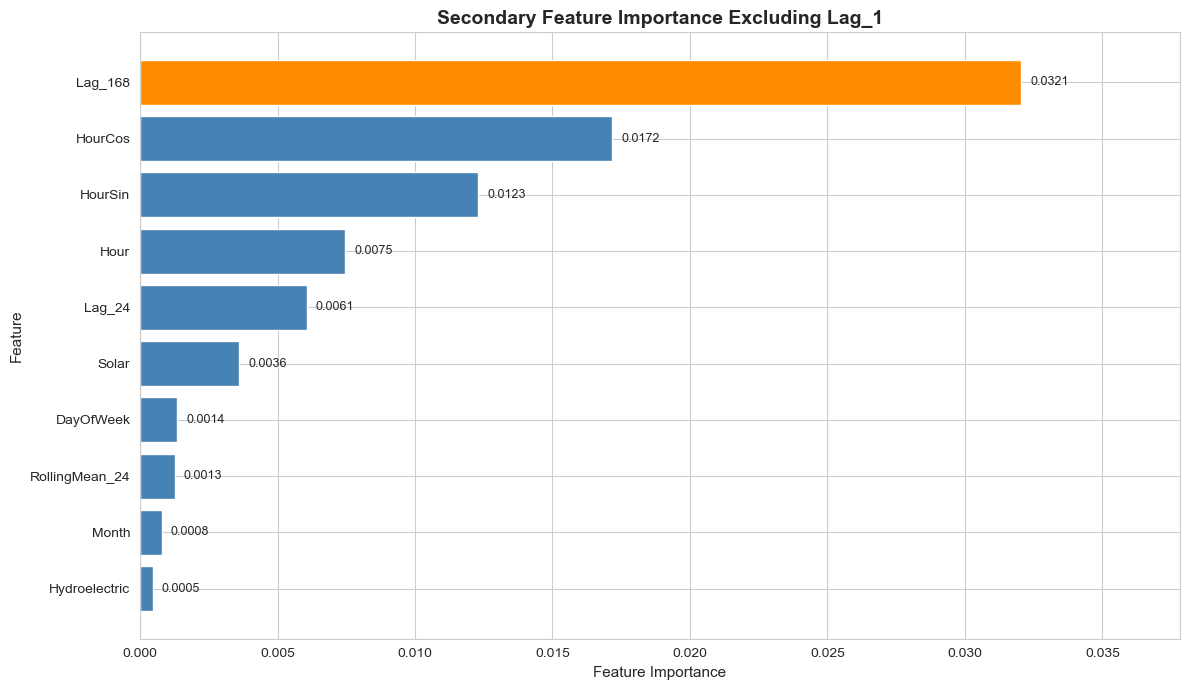


SECONDARY FEATURE IMPORTANCE EXCLUDING LAG_1
       Feature Importance
       Lag_168   0.032054
       HourCos   0.017175
       HourSin   0.012300
          Hour   0.007471
        Lag_24   0.006079
         Solar   0.003616
     DayOfWeek   0.001357
RollingMean_24   0.001274
         Month   0.000795
 Hydroelectric   0.000465


In [37]:
# ============================================================
# Section 5.7 Feature Importance Analysis
# Final Gradient Boosting Model
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Check required variables
# ------------------------------------------------------------
if "gb_model" not in globals():
    raise NameError(
        "gb_model is not defined. "
        "Please run Section 5.6 Comparative Model Evaluation first."
    )

if "X_train" not in globals():
    raise NameError(
        "X_train is not defined. "
        "Please run the data preparation and train-test split first."
    )


# ------------------------------------------------------------
# 2. Obtain feature names
# ------------------------------------------------------------
if hasattr(X_train, "columns"):
    feature_names = list(X_train.columns)
else:
    feature_names = [
        f"Feature_{index + 1}"
        for index in range(X_train.shape[1])
    ]


# ------------------------------------------------------------
# 3. Obtain feature importance values
# ------------------------------------------------------------
feature_importance_values = gb_model.feature_importances_

if len(feature_names) != len(feature_importance_values):
    raise ValueError(
        "The number of feature names does not match "
        "the number of feature importance values."
    )


# ------------------------------------------------------------
# 4. Create the complete feature importance table
# ------------------------------------------------------------
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance_values
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Display the complete feature importance ranking
# ------------------------------------------------------------
print("=" * 70)
print("SECTION 5.7 GRADIENT BOOSTING FEATURE IMPORTANCE")
print("=" * 70)

print(
    importance_df.to_string(
        index=False,
        formatters={
            "Importance": lambda value: f"{value:.6f}"
        }
    )
)


# ============================================================
# Figure Top 15 Feature Importances Including Lag_1
# ============================================================

top_15_features = (
    importance_df
    .head(15)
    .sort_values(
        by="Importance",
        ascending=True
    )
    .reset_index(drop=True)
)

# Set all bars to blue and highlight the highest feature
bar_colors_1 = ["steelblue"] * len(top_15_features)

highest_index_1 = top_15_features["Importance"].idxmax()
bar_colors_1[highest_index_1] = "darkorange"

plt.figure(figsize=(12, 7))

bars_1 = plt.barh(
    top_15_features["Feature"],
    top_15_features["Importance"],
    color=bar_colors_1
)

plt.title(
    "Top 15 Gradient Boosting Feature Importances",
    fontsize=14,
    fontweight="semibold"
)

plt.xlabel(
    "Feature Importance",
    fontsize=11
)

plt.ylabel(
    "Feature",
    fontsize=11
)

maximum_importance_1 = top_15_features["Importance"].max()

for bar, value in zip(
    bars_1,
    top_15_features["Importance"]
):
    plt.text(
        value + maximum_importance_1 * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

plt.xlim(
    0,
    maximum_importance_1 * 1.16
)

plt.tight_layout()

plt.savefig(
    "figure_5_7a_top_15_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Figure Secondary Feature Importance Excluding Lag_1
# ============================================================

secondary_importance_df = (
    importance_df[
        importance_df["Feature"] != "Lag_1"
    ]
    .head(10)
    .sort_values(
        by="Importance",
        ascending=True
    )
    .reset_index(drop=True)
)

if secondary_importance_df.empty:
    raise ValueError(
        "No features are available after excluding Lag_1."
    )

# Set all bars to blue and highlight the highest secondary feature
bar_colors_2 = ["steelblue"] * len(secondary_importance_df)

highest_index_2 = secondary_importance_df["Importance"].idxmax()
bar_colors_2[highest_index_2] = "darkorange"

plt.figure(figsize=(12, 7))

bars_2 = plt.barh(
    secondary_importance_df["Feature"],
    secondary_importance_df["Importance"],
    color=bar_colors_2
)

plt.title(
    "Secondary Feature Importance Excluding Lag_1",
    fontsize=14,
    fontweight="semibold"
)

plt.xlabel(
    "Feature Importance",
    fontsize=11
)

plt.ylabel(
    "Feature",
    fontsize=11
)

maximum_importance_2 = (
    secondary_importance_df["Importance"].max()
)

for bar, value in zip(
    bars_2,
    secondary_importance_df["Importance"]
):
    plt.text(
        value + maximum_importance_2 * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

plt.xlim(
    0,
    maximum_importance_2 * 1.18
)

plt.tight_layout()

plt.savefig(
    "figure_5_7b_secondary_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. Display the secondary feature ranking
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SECONDARY FEATURE IMPORTANCE EXCLUDING LAG_1")
print("=" * 70)

print(
    secondary_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .to_string(
        index=False,
        formatters={
            "Importance": lambda value: f"{value:.6f}"
        }
    )
)

##  5.8 Advanced Deep Learning Model (LSTM)

SECTION 5.8 LSTM WITH DATA AUGMENTATION

Training shape: (43660, 21)
Test shape: (18982, 21)

Chronological LSTM split:
LSTM training observations: 34928
LSTM validation observations: 8732
Independent test observations: 18982

Sequence shapes:
Training sequences: (34905, 24, 21)
Validation sequences: (8732, 24, 21)
Test sequences: (18982, 24, 21)

Sequence alignment:
Training input window: X[t-23] to X[t]
Target: y[t]
Latest demand information: Lag_1[t] = y[t-1]

Original sequence training shape:
(34905, 24, 21)

Augmented sequence training shape:
(69810, 24, 21)

LSTM model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,521 (138.75 KB)

 Trainable params: 35,521 (138.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.1489 - val_loss: 0.0837
Epoch 2/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0549 - val_loss: 0.0458
Epoch 3/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0371 - val_loss: 0.0346
Epoch 4/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0285 - val_loss: 0.0270
Epoch 5/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0232 - val_loss: 0.0258
Epoch 6/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0196 - val_loss: 0.0244
Epoch 7/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0163 - val_loss: 0.0253
Epoch 8/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0161 - val_loss: 0.0232
Epoch 9/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0142 - val_loss: 0.0261
Epoch 10/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0131 - val_loss: 0.0236
Epoch 11/30
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0126 - val_loss: 0.0253
Epoch 12/30
1091/1091 ━━━━━━

,Model,MAE,RMSE,R2,Training Time
0,LSTM + Augmentation,180.07,256.42,0.9401,123.0


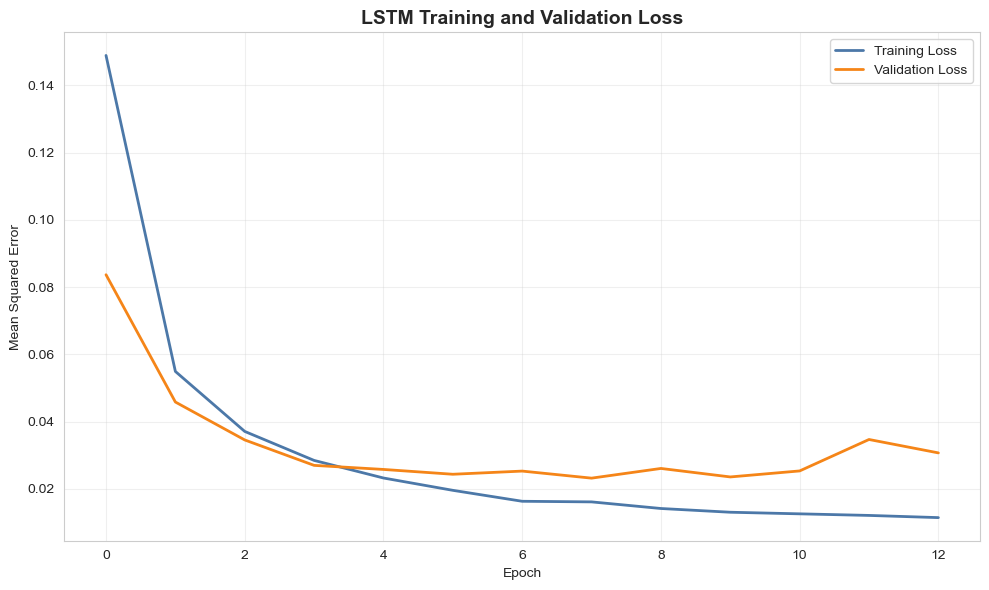

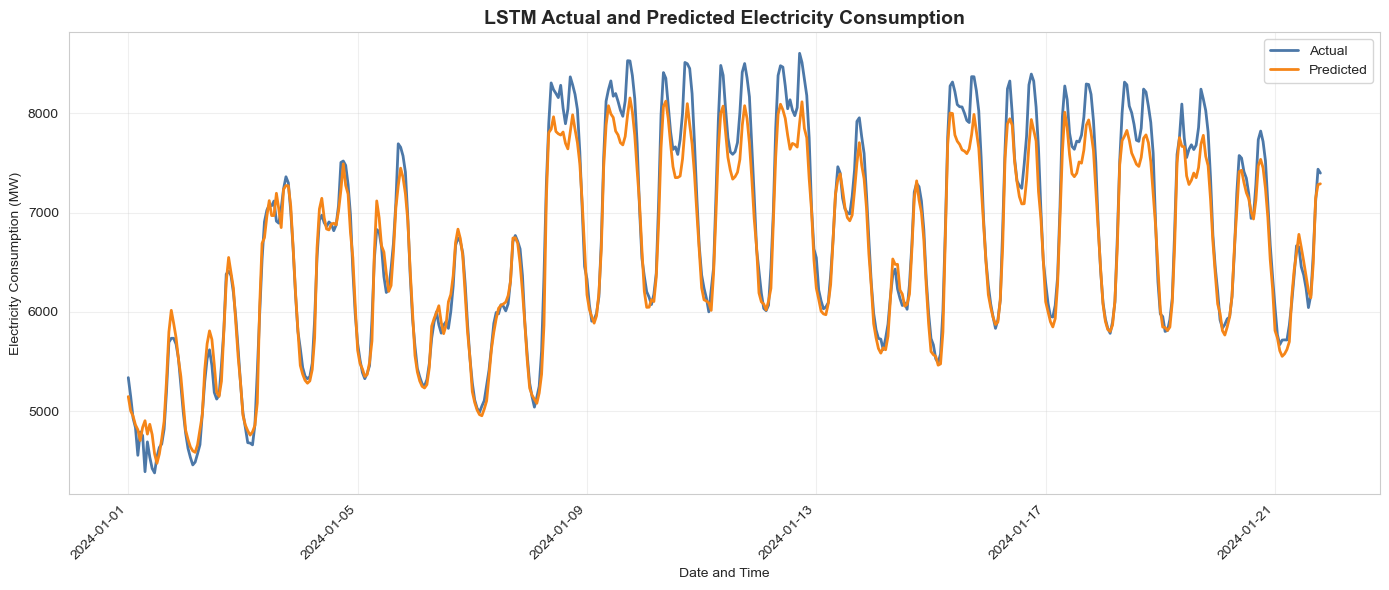

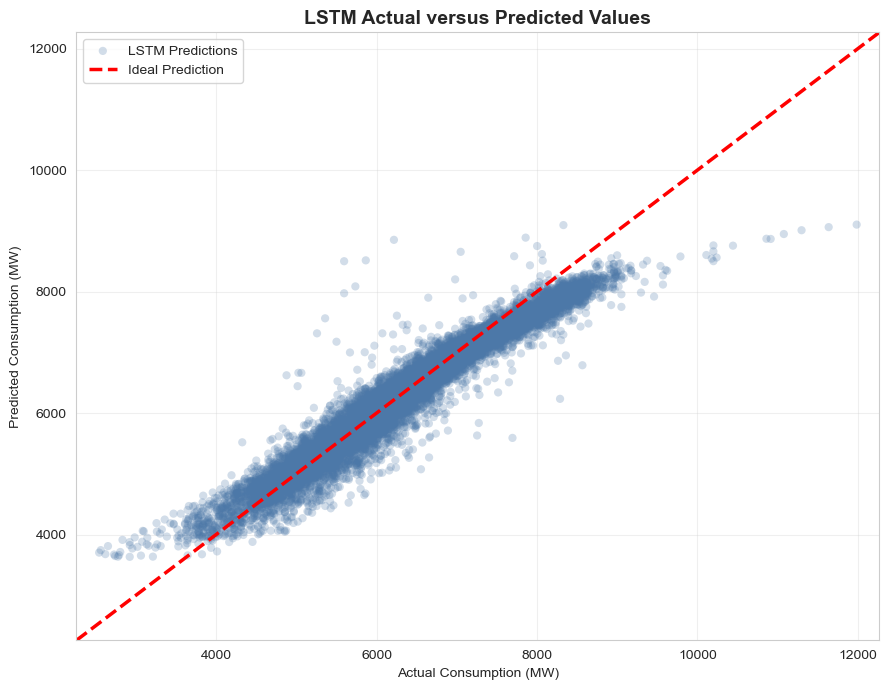


First five LSTM predictions:


,DateTime,Actual,LSTM Prediction,Residual
0,2024-01-01 00:00:00,5338.0,5147.267090,190.732910
1,2024-01-01 01:00:00,5148.0,5003.587891,144.412109
2,2024-01-01 02:00:00,4931.0,4950.263672,-19.263672
3,2024-01-01 03:00:00,4836.0,4862.081543,-26.081543
4,2024-01-01 04:00:00,4556.0,4813.350586,-257.350586



Saved variables for Section 5.9:
- lstm_results
- lstm_pred
- y_lstm_actual
- lstm_training_time


In [38]:
# ============================================================
# Section 5.8 LSTM Model with Data Augmentation
# Complete Version
# ============================================================

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. Reproducibility and Required-Variable Checks
# ============================================================

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

required_variables = [
    "X_train",
    "X_test",
    "y_train",
    "y_test"
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise NameError(
            f"{variable_name} is not available. "
            "Run the data-preparation and train-test split sections first."
        )

if len(X_train) != len(y_train):
    raise ValueError(
        "X_train and y_train are not aligned."
    )

if len(X_test) != len(y_test):
    raise ValueError(
        "X_test and y_test are not aligned."
    )

if hasattr(X_train, "columns") and hasattr(X_test, "columns"):
    if X_train.columns.tolist() != X_test.columns.tolist():
        raise ValueError(
            "Training and test predictor columns do not match."
        )

print("=" * 70)
print("SECTION 5.8 LSTM WITH DATA AUGMENTATION")
print("=" * 70)

print("\nTraining shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ============================================================
# 2. Convert Data to NumPy Arrays
# ============================================================

X_train_lstm_source = np.asarray(
    X_train,
    dtype=np.float32
)

X_test_lstm_source = np.asarray(
    X_test,
    dtype=np.float32
)

y_train_lstm_source = np.asarray(
    y_train,
    dtype=np.float32
).reshape(-1, 1)

y_test_lstm_source = np.asarray(
    y_test,
    dtype=np.float32
).reshape(-1, 1)


# ============================================================
# 3. Chronological Training-Validation Split
# Final 20% of the pre-2024 development period is validation
# ============================================================

validation_fraction = 0.20

validation_size = int(
    len(X_train_lstm_source) * validation_fraction
)

if validation_size <= 0:
    raise ValueError(
        "Validation size is zero. "
        "The training dataset is too small."
    )

split_position = (
    len(X_train_lstm_source) - validation_size
)

X_lstm_train_raw = X_train_lstm_source[
    :split_position
]

X_lstm_val_raw = X_train_lstm_source[
    split_position:
]

y_lstm_train_raw = y_train_lstm_source[
    :split_position
]

y_lstm_val_raw = y_train_lstm_source[
    split_position:
]

print("\nChronological LSTM split:")
print("LSTM training observations:", len(X_lstm_train_raw))
print("LSTM validation observations:", len(X_lstm_val_raw))
print("Independent test observations:", len(X_test_lstm_source))


# ============================================================
# 4. Fit Scalers Using LSTM Training Subset Only
# ============================================================

X_lstm_scaler = StandardScaler()
y_lstm_scaler = StandardScaler()

X_lstm_train_scaled = X_lstm_scaler.fit_transform(
    X_lstm_train_raw
)

X_lstm_val_scaled = X_lstm_scaler.transform(
    X_lstm_val_raw
)

X_lstm_test_scaled = X_lstm_scaler.transform(
    X_test_lstm_source
)

y_lstm_train_scaled = y_lstm_scaler.fit_transform(
    y_lstm_train_raw
)

y_lstm_val_scaled = y_lstm_scaler.transform(
    y_lstm_val_raw
)

y_lstm_test_scaled = y_lstm_scaler.transform(
    y_test_lstm_source
)


# ============================================================
# 5. Create 24-Hour Sequences
# ============================================================

# ============================================================
# 5. Create 24-Hour Sequences
# Include X[t] when predicting y[t]
# ============================================================

TIME_STEPS = 24


def create_sequences(
    X_array,
    y_array,
    time_steps=24
):
    """
    Create a 24-hour input window ending at the target time.

    For target y[t], the input sequence contains:

    X[t-23], X[t-22], ..., X[t]

    Because Consumption is excluded from X, this does not
    directly expose y[t] to the model. However, X[t] contains
    Lag_1[t], which correctly represents y[t-1].
    """

    X_sequences = []
    y_sequences = []

    for index in range(
        time_steps - 1,
        len(X_array)
    ):
        X_sequences.append(
            X_array[
                index - time_steps + 1:index + 1
            ]
        )

        y_sequences.append(
            y_array[index]
        )

    return (
        np.asarray(
            X_sequences,
            dtype=np.float32
        ),
        np.asarray(
            y_sequences,
            dtype=np.float32
        )
    )


# ============================================================
# 5.1 Create Training Sequences
# ============================================================

X_lstm_train_seq, y_lstm_train_seq = create_sequences(
    X_lstm_train_scaled,
    y_lstm_train_scaled,
    TIME_STEPS
)


# ============================================================
# 5.2 Create Validation Sequences
# ============================================================

# To predict the first validation observation, the model needs
# the previous 23 predictor rows from the training period plus
# the current validation predictor row.

validation_context_length = (
    TIME_STEPS - 1
)

X_lstm_val_context = np.vstack([
    X_lstm_train_scaled[
        -validation_context_length:
    ],
    X_lstm_val_scaled
])

y_lstm_val_context = np.vstack([
    y_lstm_train_scaled[
        -validation_context_length:
    ],
    y_lstm_val_scaled
])

X_lstm_val_seq, y_lstm_val_seq = create_sequences(
    X_lstm_val_context,
    y_lstm_val_context,
    TIME_STEPS
)


# ============================================================
# 5.3 Create Independent Test Sequences
# ============================================================

# The first test prediction uses the previous 23 observations
# from the complete pre-2024 development period together with
# X[t] for the first test timestamp.

test_context_length = (
    TIME_STEPS - 1
)

X_lstm_test_context = np.vstack([
    X_lstm_scaler.transform(
        X_train_lstm_source[
            -test_context_length:
        ]
    ),
    X_lstm_test_scaled
])

y_lstm_test_context = np.vstack([
    y_lstm_scaler.transform(
        y_train_lstm_source[
            -test_context_length:
        ]
    ),
    y_lstm_test_scaled
])

X_lstm_test_seq, y_lstm_test_seq = create_sequences(
    X_lstm_test_context,
    y_lstm_test_context,
    TIME_STEPS
)


# ============================================================
# 5.4 Validate Sequence Alignment
# ============================================================

if len(X_lstm_val_seq) != len(
    X_lstm_val_scaled
):
    raise ValueError(
        "Validation sequence count does not match "
        "the validation observation count."
    )

if len(X_lstm_test_seq) != len(
    X_lstm_test_scaled
):
    raise ValueError(
        "Test sequence count does not match "
        "the independent test observation count."
    )

if len(y_lstm_test_seq) != len(
    y_test_lstm_source
):
    raise ValueError(
        "LSTM test targets are not aligned with y_test."
    )

print("\nSequence shapes:")

print(
    "Training sequences:",
    X_lstm_train_seq.shape
)

print(
    "Validation sequences:",
    X_lstm_val_seq.shape
)

print(
    "Test sequences:",
    X_lstm_test_seq.shape
)

print("\nSequence alignment:")

print(
    "Training input window:",
    "X[t-23] to X[t]"
)

print(
    "Target:",
    "y[t]"
)

print(
    "Latest demand information:",
    "Lag_1[t] = y[t-1]"
)


# ============================================================
# 6. Training-Sequence Data Augmentation
# Gaussian noise is applied only to training sequences
# ============================================================

NOISE_LEVEL = 0.01

noise = np.random.normal(
    loc=0.0,
    scale=NOISE_LEVEL,
    size=X_lstm_train_seq.shape
).astype(np.float32)

X_lstm_train_noisy = (
    X_lstm_train_seq + noise
)

X_lstm_train_augmented = np.concatenate(
    [
        X_lstm_train_seq,
        X_lstm_train_noisy
    ],
    axis=0
)

y_lstm_train_augmented = np.concatenate(
    [
        y_lstm_train_seq,
        y_lstm_train_seq
    ],
    axis=0
)

print("\nOriginal sequence training shape:")
print(X_lstm_train_seq.shape)

print("\nAugmented sequence training shape:")
print(X_lstm_train_augmented.shape)


# ============================================================
# 7. Build the LSTM Model
# ============================================================

lstm_model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_lstm_train_augmented.shape[1],
            X_lstm_train_augmented.shape[2]
        )
    ),

    Dropout(0.20),

    LSTM(
        32
    ),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

print("\nLSTM model summary:")
lstm_model.summary()


# ============================================================
# 8. Train the LSTM Model
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history = lstm_model.fit(
    X_lstm_train_augmented,
    y_lstm_train_augmented,
    validation_data=(
        X_lstm_val_seq,
        y_lstm_val_seq
    ),
    epochs=30,
    batch_size=64,
    shuffle=False,
    callbacks=[
        early_stopping
    ],
    verbose=1
)

lstm_training_time = (
    time.time() - start_time
)


# ============================================================
# 9. Generate Independent Test Predictions
# ============================================================

lstm_pred_scaled = lstm_model.predict(
    X_lstm_test_seq,
    verbose=1
)

lstm_pred = (
    y_lstm_scaler
    .inverse_transform(
        lstm_pred_scaled
    )
    .ravel()
)

y_lstm_actual = (
    y_lstm_scaler
    .inverse_transform(
        y_lstm_test_seq
    )
    .ravel()
)

if len(lstm_pred) != len(y_test):
    raise ValueError(
        "The LSTM prediction count does not match "
        "the independent test-set size."
    )


# ============================================================
# 10. Evaluate LSTM Test Performance
# ============================================================

lstm_mae = mean_absolute_error(
    y_lstm_actual,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_lstm_actual,
        lstm_pred
    )
)

lstm_r2 = r2_score(
    y_lstm_actual,
    lstm_pred
)

print("\n" + "=" * 70)
print("LSTM + AUGMENTATION TEST PERFORMANCE")
print("=" * 70)

print(
    f"MAE: {lstm_mae:.2f} MW"
)

print(
    f"RMSE: {lstm_rmse:.2f} MW"
)

print(
    f"R²: {lstm_r2:.4f}"
)

print(
    f"Training time: "
    f"{lstm_training_time:.2f} seconds"
)

print(
    f"Evaluation samples: "
    f"{len(y_lstm_actual)}"
)


# ============================================================
# 11. Save LSTM Results for Section 5.9
# This variable resolves the earlier NameError in Section 5.9
# ============================================================

lstm_results = pd.DataFrame({
    "Model": [
        "LSTM + Augmentation"
    ],
    "MAE": [
        lstm_mae
    ],
    "RMSE": [
        lstm_rmse
    ],
    "R2": [
        lstm_r2
    ],
    "Training Time": [
        lstm_training_time
    ]
})

print("\nTABLE 5.8 LSTM PERFORMANCE")

display(
    lstm_results.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 4,
        "Training Time": 2
    })
)


# ============================================================
# 12. Prepare Test Timestamps
# ============================================================

if "test_timestamps" in globals():
    lstm_test_timestamps = pd.to_datetime(
        np.asarray(
            test_timestamps
        )
    )

elif hasattr(X_test, "index"):
    try:
        lstm_test_timestamps = pd.to_datetime(
            X_test.index
        )
    except Exception:
        lstm_test_timestamps = np.arange(
            len(y_lstm_actual)
        )

else:
    lstm_test_timestamps = np.arange(
        len(y_lstm_actual)
    )

if len(lstm_test_timestamps) != len(y_lstm_actual):
    lstm_test_timestamps = np.arange(
        len(y_lstm_actual)
    )


# ============================================================
# 13. Figure Training and Validation Loss
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history.history["loss"],
    color="#4C78A8",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    color="#F58518",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.title(
    "LSTM Training and Validation Loss",
    fontsize=14,
    weight="semibold"
)

plt.legend()
plt.grid(alpha=0.30)
plt.tight_layout()

plt.savefig(
    "figure_5_8a_lstm_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. Figure Actual and Predicted Consumption
# First 500 test observations
# ============================================================

plot_length = min(
    500,
    len(y_lstm_actual)
)

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    lstm_test_timestamps[:plot_length],
    y_lstm_actual[:plot_length],
    color="#4C78A8",
    linewidth=2,
    label="Actual"
)

plt.plot(
    lstm_test_timestamps[:plot_length],
    lstm_pred[:plot_length],
    color="#F58518",
    linewidth=2,
    label="Predicted"
)

plt.xlabel("Date and Time")
plt.ylabel("Electricity Consumption (MW)")

plt.title(
    "LSTM Actual and Predicted Electricity Consumption",
    fontsize=14,
    weight="semibold"
)

plt.legend()
plt.grid(alpha=0.30)
plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "figure_5_8b_lstm_actual_predicted_time_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. Figure Actual versus Predicted Scatter Plot
# Red ideal-prediction line
# ============================================================

minimum_value = min(
    np.min(y_lstm_actual),
    np.min(lstm_pred)
)

maximum_value = max(
    np.max(y_lstm_actual),
    np.max(lstm_pred)
)

axis_padding = (
    maximum_value - minimum_value
) * 0.03

lower_limit = (
    minimum_value - axis_padding
)

upper_limit = (
    maximum_value + axis_padding
)

plt.figure(
    figsize=(9, 7)
)

plt.scatter(
    y_lstm_actual,
    lstm_pred,
    color="#4C78A8",
    alpha=0.25,
    s=35,
    edgecolors="none",
    label="LSTM Predictions"
)

plt.plot(
    [
        lower_limit,
        upper_limit
    ],
    [
        lower_limit,
        upper_limit
    ],
    color="red",
    linestyle="--",
    linewidth=2.5,
    label="Ideal Prediction"
)

plt.xlabel("Actual Consumption (MW)")
plt.ylabel("Predicted Consumption (MW)")

plt.title(
    "LSTM Actual versus Predicted Values",
    fontsize=14,
    weight="semibold"
)

plt.xlim(
    lower_limit,
    upper_limit
)

plt.ylim(
    lower_limit,
    upper_limit
)

plt.legend()
plt.grid(alpha=0.30)
plt.tight_layout()

plt.savefig(
    "figure_5_8c_lstm_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. Save Prediction-Level LSTM Results
# ============================================================

lstm_prediction_results = pd.DataFrame({
    "DateTime": lstm_test_timestamps,
    "Actual": y_lstm_actual,
    "LSTM Prediction": lstm_pred,
    "Residual": (
        y_lstm_actual - lstm_pred
    )
})

print("\nFirst five LSTM predictions:")

display(
    lstm_prediction_results.head()
)

print("\nSaved variables for Section 5.9:")
print("- lstm_results")
print("- lstm_pred")
print("- y_lstm_actual")
print("- lstm_training_time")

# 5.9 Comparative Analysis of All Models

TABLE 5.9 FINAL PERFORMANCE COMPARISON


,Model,MAE,RMSE,R2,Training Time
0,Gradient Boosting,132.82,200.42,0.9634,58.64
1,LSTM + Augmentation,180.07,256.42,0.9401,123.00



Best overall model based on RMSE:
Gradient Boosting
MAE: 132.82 MW
RMSE: 200.42 MW
R²: 0.9634


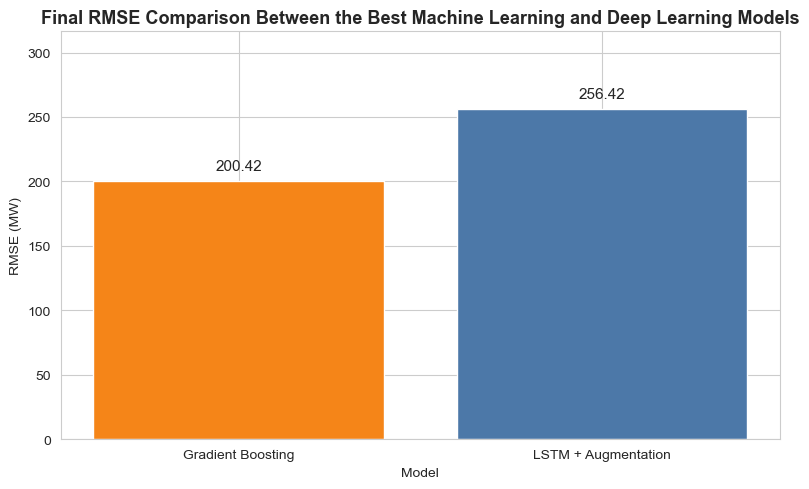


RMSE difference:
56.00 MW
Best ML model RMSE reduction relative to LSTM:
21.84%


In [ ]:
# ============================================================
# Section 5.9 Final Model Comparison
# Best Machine Learning Model vs LSTM
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Check Required Results
# ============================================================

required_variables = [
    "results_df",
    "lstm_results"
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise NameError(
            f"{variable_name} is not available. "
            "Run Sections 5.6 and 5.8 first."
        )

# ============================================================
# 2. Select Best Machine Learning Model
# ============================================================

# results_df has already been sorted by RMSE
best_ml_result = results_df.iloc[[0]].copy()

# Retain the LSTM result
best_dl_result = lstm_results.copy()

# Standardise column names
required_columns = [
    "Model",
    "MAE",
    "RMSE",
    "R2",
    "Training Time"
]

missing_ml_columns = [
    column
    for column in required_columns
    if column not in best_ml_result.columns
]

missing_dl_columns = [
    column
    for column in required_columns
    if column not in best_dl_result.columns
]

if missing_ml_columns:
    raise KeyError(
        "The following columns are missing from results_df: "
        f"{missing_ml_columns}"
    )

if missing_dl_columns:
    raise KeyError(
        "The following columns are missing from lstm_results: "
        f"{missing_dl_columns}"
    )

best_ml_result = best_ml_result[
    required_columns
]

best_dl_result = best_dl_result[
    required_columns
]

# ============================================================
# 3. Create Final Comparison Table
# ============================================================

final_results = pd.concat(
    [
        best_ml_result,
        best_dl_result
    ],
    axis=0,
    ignore_index=True
)

final_results = (
    final_results
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("TABLE 5.9 FINAL PERFORMANCE COMPARISON")
print("=" * 70)

display(
    final_results.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 4,
        "Training Time": 2
    })
)

# ============================================================
# 4. Automatically Identify Final Best Model
# ============================================================

final_best_model = final_results.iloc[0]

print("\nBest overall model based on RMSE:")
print(final_best_model["Model"])

print(
    f"MAE: {final_best_model['MAE']:.2f} MW"
)

print(
    f"RMSE: {final_best_model['RMSE']:.2f} MW"
)

print(
    f"R²: {final_best_model['R2']:.4f}"
)

# ============================================================
# 5. Figure Final RMSE Comparison
# Highlight the best overall model
# ============================================================

# Default colour for all models
bar_colours = ["#4C78A8"] * len(final_results)

# Highlight the model with the lowest RMSE
best_bar_position = int(
    np.argmin(
        final_results["RMSE"].to_numpy()
    )
)

bar_colours[best_bar_position] = "#F58518"

plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    final_results["Model"],
    final_results["RMSE"],
    color=bar_colours
)

for bar, value in zip(
    bars,
    final_results["RMSE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 6,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.xlabel("Model")
plt.ylabel("RMSE (MW)")

plt.title(
    "Final RMSE Comparison Between the Best "
    "Machine Learning and Deep Learning Models",
    fontsize=13,
    weight="semibold"
)

plt.ylim(
    0,
    final_results["RMSE"].max() + 60
)

plt.tight_layout()

plt.savefig(
    "figure_5_9_final_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 6. Quantify Performance Difference
# ============================================================

ml_rmse = float(
    best_ml_result["RMSE"].iloc[0]
)

lstm_rmse_value = float(
    best_dl_result["RMSE"].iloc[0]
)

rmse_difference = (
    lstm_rmse_value - ml_rmse
)

rmse_improvement_percentage = (
    rmse_difference / lstm_rmse_value
) * 100

print("\nRMSE difference:")
print(
    f"{rmse_difference:.2f} MW"
)

print(
    "Best ML model RMSE reduction relative to LSTM:"
)

print(
    f"{rmse_improvement_percentage:.2f}%"
)